In [1]:
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import pickle
import math
import scipy
from pathlib import Path
import sys
import os
import warnings
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from matplotlib.ticker import ScalarFormatter
from copy import deepcopy
sys.path.append("../src")
from custom_distance import KL, conditionKL
import itertools


import plotly.express as px

import plotly.io as pio
pio.renderers.default = 'iframe' # or 'notebook' or 'colab' or 'jupyterlab' iframe

from plotly.express.colors import sample_colorscale

import plotly.graph_objects as go


warnings.filterwarnings("ignore")


def get_regression(x, y):
    x = sm.add_constant(x)
    
    lr_fit = sm.OLS(y, x)
    results = lr_fit.fit()

    return results.params[-1], results


def get_coefLog10(x, y):
    x = np.log10(x)
    x = sm.add_constant(x)
    
    lr_fit = sm.OLS(y, x)
    results = lr_fit.fit()

    return results.params[-1], results


In [10]:
set_alpha_train_DICT = {566:5, 3636:1, 6621:0.2,
                        1152:5, 6114:1, 11063:0.2, 

                       }

# Task Vector Comparison Plot

In [3]:
sns.reset_defaults()
sns.set_theme(style="ticks", rc={"figure.dpi": 350})


In [4]:
# sets_ls = [6621, 3636, 566]
# alpha_train_ls = [0.2,1,5]
# sets_reduce_ls = [6621, 566]
# alpha_train_reduce_ls = [0.2, 5]
# dataset_name = 'HateSpeech'
# # dataset_name = 'CD'

sets_ls = [11063, 6114, 1152]
alpha_train_ls = [0.2, 1, 5]
sets_reduce_ls = [11063, 1152]
alpha_train_reduce_ls = [0.2, 5]
dataset_name = 'SHAC'


# modelUsed = "Llama"
modelUsed = "RoBERTa"

if modelUsed == "Llama":
    fname_base = "../output/tmpData/{}/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl"
    fname_edited = "../output/tmpData/{}/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5.pkl"

    fname_reverse_base = "../output/tmpData/{}_ReverseSource/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl"
    fname_reverse_edited = "../output/tmpData/{}_ReverseSource/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5.pkl"
elif modelUsed == "RoBERTa":
    fname_base = "../output/roberta/{}/Eval-set-{}-epoch3-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl"
    fname_edited = "../output/roberta/{}/Eval-set-{}-epoch3-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5.pkl"

    fname_reverse_base = "../output/roberta/{}_ReverseSource/Eval-set-{}-epoch3-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl"
    fname_reverse_edited = "../output/roberta/{}_ReverseSource/Eval-set-{}-epoch3-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5.pkl"



In [5]:
df_ls = []

for set_i in sets_ls:
    for nm in [fname_base, fname_edited, fname_reverse_base, fname_reverse_edited]:
        with open(nm.format(dataset_name, set_i), "rb") as f:
            df_tmp = pickle.load(file=f)
            
        df_tmp['set'] = set_i
        
        if "lambda2_0.0" in nm:
            df_tmp["lambda1_lambda2"] = "1.0-0.0"
            df_tmp["lambda2"] = 0.0
        elif "lambda2_1.0" in nm:
            df_tmp["lambda1_lambda2"] = "1.0-1.0"
            df_tmp["lambda2"] = 1.0
            
        if "Reverse" in nm:
            df_tmp['tv_direction'] = 'ReverseSource'
        else:
            df_tmp['tv_direction'] = 'Source'
        
        df_ls.append(df_tmp)
        del df_tmp
        
df_eval = pd.concat(df_ls).reset_index(drop=True)    


In [6]:
fname_backdoor = "../output/backdoor/{}/backdoor/Eval-set-{}-irun-0-ntest_200-Runs_5.pkl"
fname_nobackdoor = "../output/backdoor/{}/noBackdoor/Eval-set-{}-irun-0-ntest_200-Runs_5.pkl"


In [7]:
df_ls = []

for set_i in sets_ls:
    for nm in [fname_backdoor]:
        with open(nm.format(dataset_name, set_i), "rb") as f:
            df_tmp = pickle.load(file=f)
            
        df_tmp['set'] = set_i
            
        if "Reverse" in nm:
            df_tmp['tv_direction'] = 'ReverseSource'
        else:
            df_tmp['tv_direction'] = 'Source'
        
        df_ls.append(df_tmp)
        del df_tmp
        
df_eval_backdoor = pd.concat(df_ls).reset_index(drop=True)    


In [8]:
df_eval.query("C_y==0.5").groupby(['C_y','C_y_test']).size()

C_y  C_y_test
0.5  0.5         18720
dtype: int64

## Original alpha test

In [9]:
### All From Source

# savefig = False
savefig = True

my_palette = sns.color_palette("colorblind", 2)
my_linestyle = ['solid','dotted']
xticks = [0.1,1,10]

sr = "Source"
# sr = "ReverseSource"

outname = f"../output/TaskVectorFigs/fig_NoDAAllSource_{dataset_name}_{modelUsed}_{sr}_Cz_0.5_Cy_0.5.png"

_df = deepcopy(df_eval)

_df = _df[_df['tv_direction'] == sr].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)

xname = "alpha_test"
ylabel = "auprc_weightsEdited"

fig, ax = plt.subplots(1,3, figsize=(12,4), sharey=True)

for i, (set_i, alpha_train) in enumerate(zip(sets_ls, alpha_train_ls)):
    df_sub = _df[_df['set'] == set_i]

    for ilambda, lambda_com in enumerate(["1.0-0.0", "1.0-1.0"]):
        
        _df_plt = df_sub[df_sub['lambda1_lambda2'] == lambda_com].copy()
        reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))
        
        sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                     c=my_palette[ilambda], 
                     linestyle=my_linestyle[ilambda], label=lambda_com + f" (coef: {reg[0]:.3f})"
                    )
        

    ax[i].set_xscale('log')
    
    ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    ax[i].axvline(1/alpha_train, color="black", linestyle='dashdot')

    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((-0.02,1.02))
    ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")


plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

In [32]:
sns.color_palette("colorblind", 3)

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)]

In [ ]:
df_eval.query("C_y==0.5").groupby(["C_y", 'C_y_test']).size()

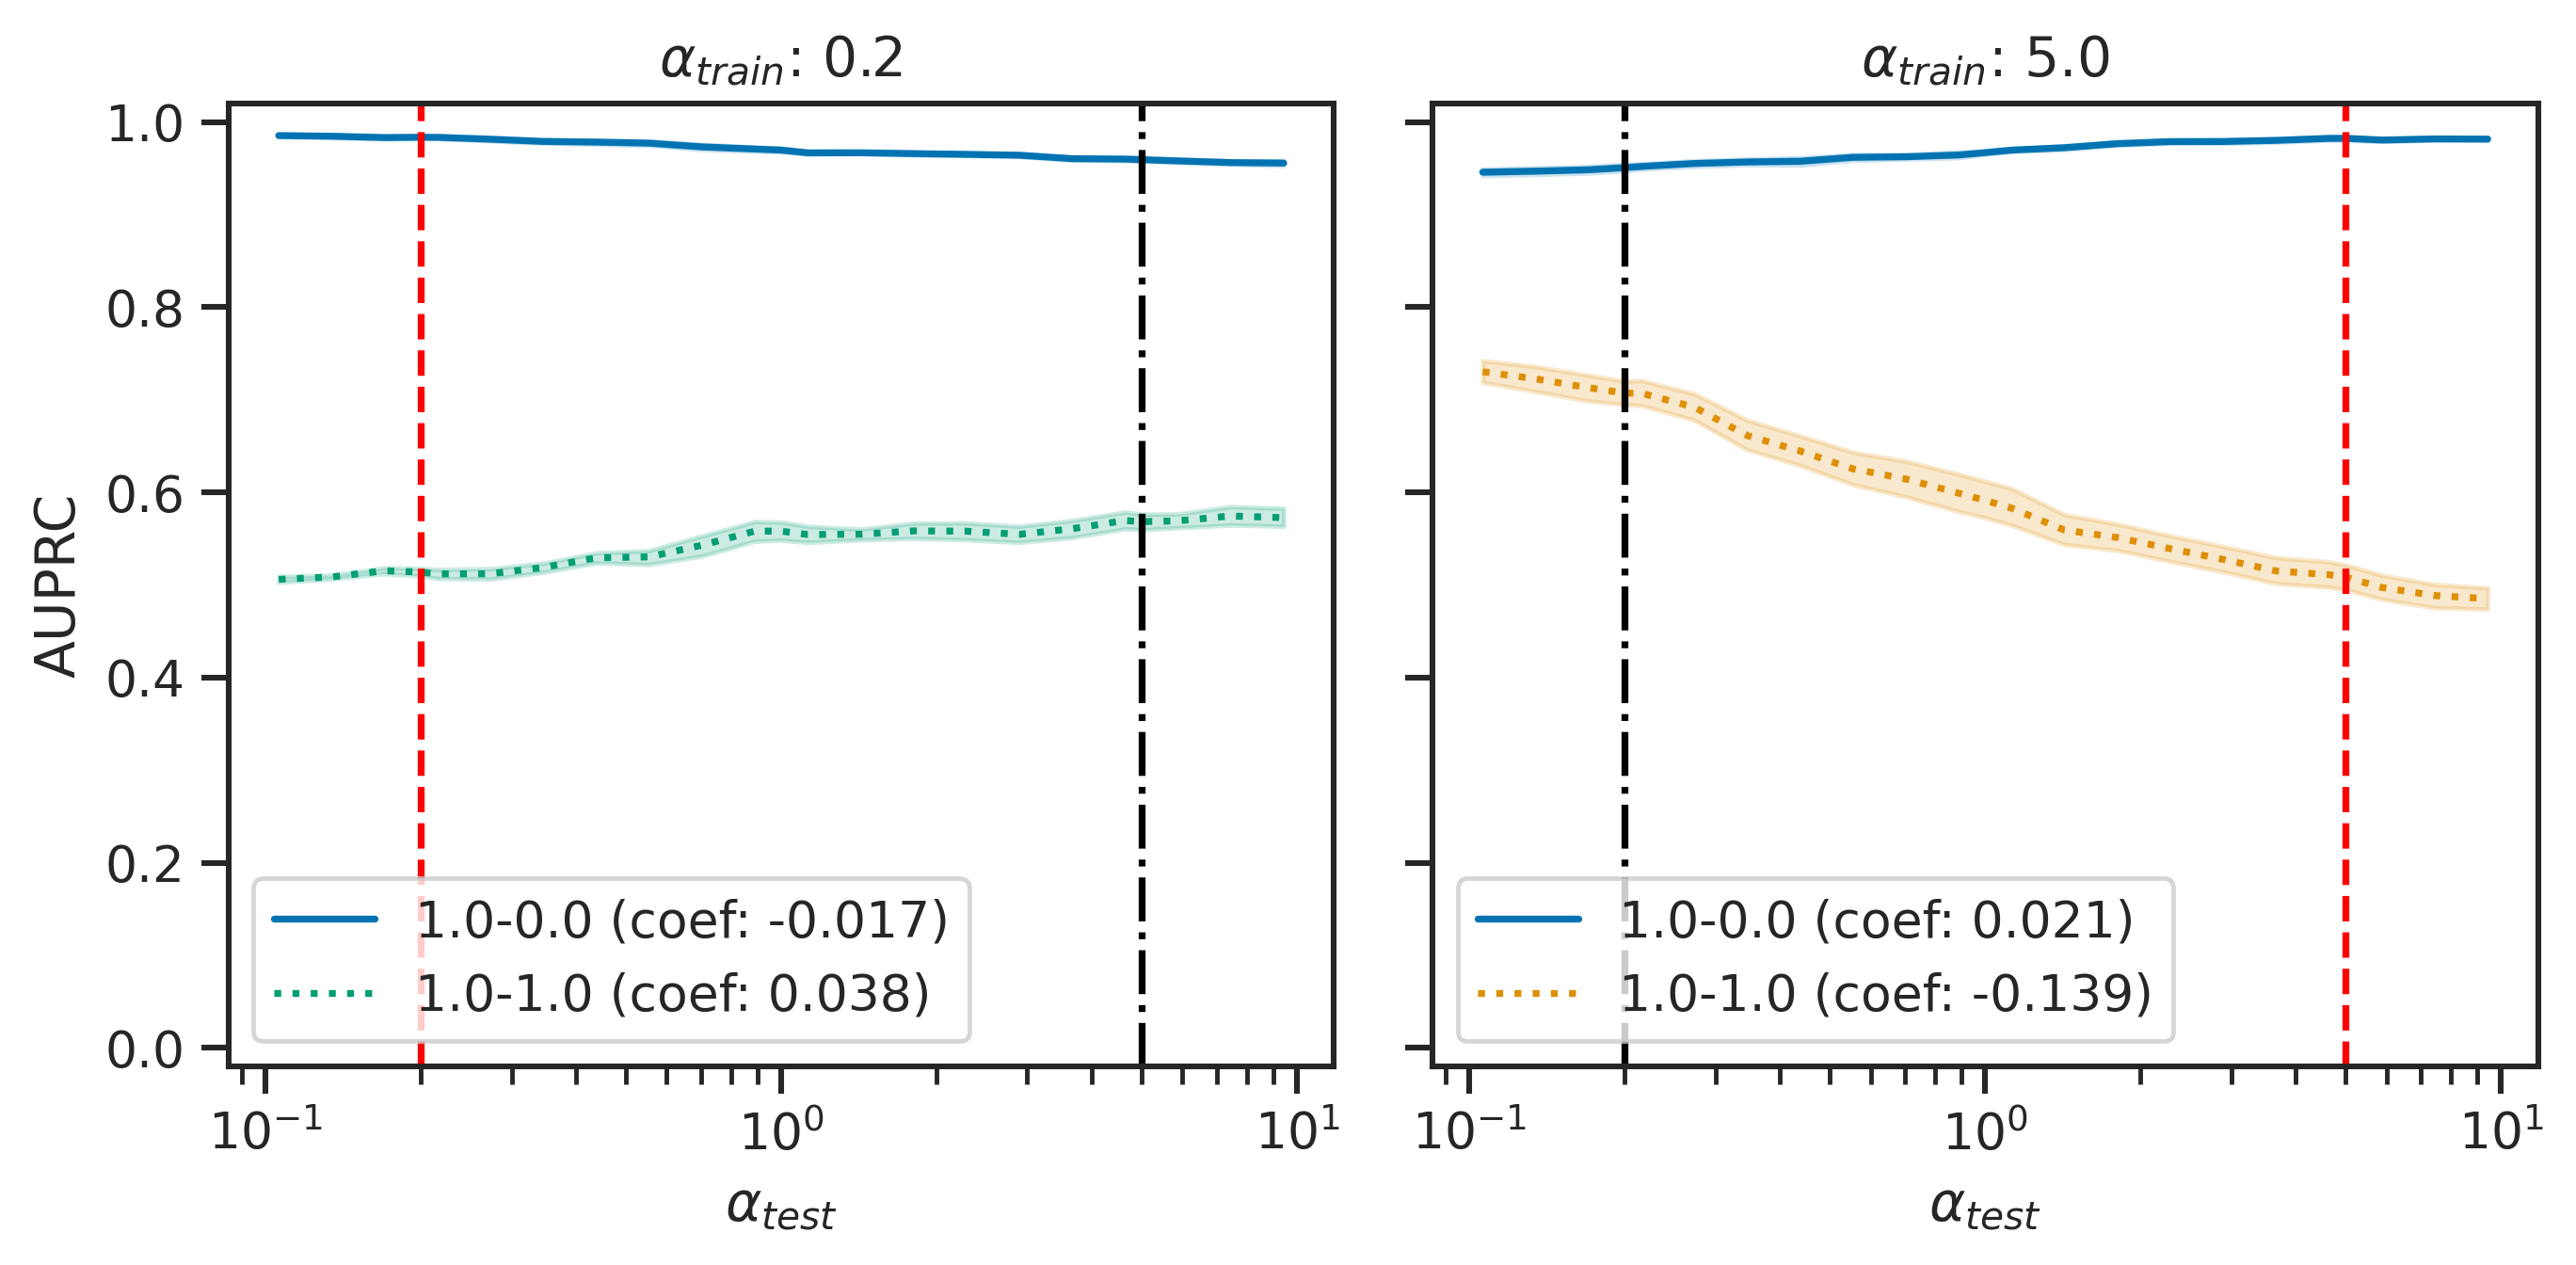

In [16]:
### Dominance-Aware Provenance Source/ReverseSource

savefig = False
# savefig = True

my_palette = sns.color_palette("colorblind", 3)
my_linestyle = ['solid','dotted']
xticks = [0.1,1,10]


outname = f"../output/TaskVectorFigs/fig_DA_{dataset_name}_{modelUsed}_Cz_0.5_Cy_0.5.png"


_df = deepcopy(df_eval)


# _df['alpha_train'] = _df['alpha_train'].apply(lambda x: 1/x if x > 1 else x)



if dataset_name in ["CD", "HateSpeech"]:
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 566)) | (_df["tv_direction"] == "ReverseSource") & (_df["set"] == 6621)].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)
elif dataset_name == "SHAC":
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 1152)) | (_df["tv_direction"] == "ReverseSource") & (_df["set"] == 11063)].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)

xname = "alpha_test"
ylabel = "auprc_weightsEdited"

# plt.figure() 
fig, ax = plt.subplots(1,2,figsize=(8,4), sharey=True)

for i, (set_i, alpha_train) in enumerate(zip(sets_reduce_ls, alpha_train_reduce_ls)):

        
    df_sub = _df[_df['set'] == set_i]

    for ilambda, lambda_com in enumerate(["1.0-0.0", "1.0-1.0"]):
        c = my_palette[ilambda]
        
        if (set_i in [6621, 11063]) and (lambda_com == "1.0-1.0"):
            c = my_palette[-1]
            
        _df_plt = df_sub[df_sub['lambda1_lambda2'] == lambda_com].copy()
        reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))
        
        sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                     c=c, 
                     linestyle=my_linestyle[ilambda], label=lambda_com + f" (coef: {reg[0]:.3f})"
                    )
        

    ax[i].set_xscale('log')
    
    ax[i].axvline(alpha_train, color="red", linestyle='dashed')
    ax[i].axvline(1/alpha_train, color="black", linestyle='dashdot')

    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((-0.02,1.02))
    ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")


plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

## Reverse alpha test when alpha train > 1

In [9]:
sns.color_palette("colorblind", 10)

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [10]:
### TAPER: All From Source - add backdoor - Three sets:0.2, 1, 5

# savefig = False
savefig = True

my_palette = sns.color_palette("colorblind", 3)
my_linestyle = ['solid','dotted','dashdot']
xticks = [0.1,1,10]

sr = "Source"
# sr = "ReverseSource"

outname = f"../output/TaskVectorFigs/fig_NoDAAllSource_{dataset_name}_{modelUsed}_{sr}_Cz_0.5_Cy_0.5.png"

_df = deepcopy(df_eval)
_df_backdoor = deepcopy(df_eval_backdoor)

_df = _df[_df['tv_direction'] == sr].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)
_df_backdoor = _df_backdoor.query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)



xname = "alpha_test"
ylabel = "auprc_weightsEdited"

# fig, ax = plt.subplots(1,2, figsize=(8,4), sharey=True)
fig, ax = plt.subplots(1,3, figsize=(12,4), sharey=True)



# for i, (set_i, alpha_train) in enumerate(zip(sets_reduce_ls, alpha_train_reduce_ls)):
for i, (set_i, alpha_train) in enumerate(zip(sets_ls, alpha_train_ls)):

    df_sub = _df[_df['set'] == set_i]
    df_sub_backdoor = _df_backdoor[_df_backdoor['set'] == set_i]

    # for ilambda, lambda_com in enumerate(["1.0-0.0", "1.0-1.0"]):
    for ilambda, lambda_com in enumerate([0.0, 1.0]):
        
        # _df_plt = df_sub[df_sub['lambda1_lambda2'] == lambda_com].copy()
        _df_plt = df_sub[df_sub['lambda2'] == lambda_com].copy()

        reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))
        
        sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                     c=my_palette[ilambda], 
                     linestyle=my_linestyle[ilambda], label=r"$\lambda$=" +f"{lambda_com:.1f}" + f" (coef: {reg[0]:.3f})"
                    )
    
    reg_backdoor = get_coefLog10(x=list(df_sub_backdoor[xname]), y=list(df_sub_backdoor[ylabel]))
    
    sns.lineplot(data=df_sub_backdoor, x=xname, y=ylabel, ax=ax[i], 
                     c='grey', 
                     linestyle=my_linestyle[2], label=r"backdoor" + f" (coef: {reg_backdoor[0]:.3f})"
                    )
        

    ax[i].set_xscale('log')
    
    ax[i].axvline(set_alpha_train_DICT[set_i], color="#4DAF4A", linestyle='dashed')
    ax[i].axvline(1/set_alpha_train_DICT[set_i], color="grey", linestyle='dashed')
    if set_alpha_train_DICT[set_i] != 1:
        ax[i].text(x=set_alpha_train_DICT[set_i], y=-0.12, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
        ax[i].text(x=1/set_alpha_train_DICT[set_i], y=-0.12, s='worst', color="grey", fontsize=10, horizontalalignment='center')

    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((-0.02,1.02))
    ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")
    
    if set_i in [566, 1152]:
        ax[i].invert_xaxis()


plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

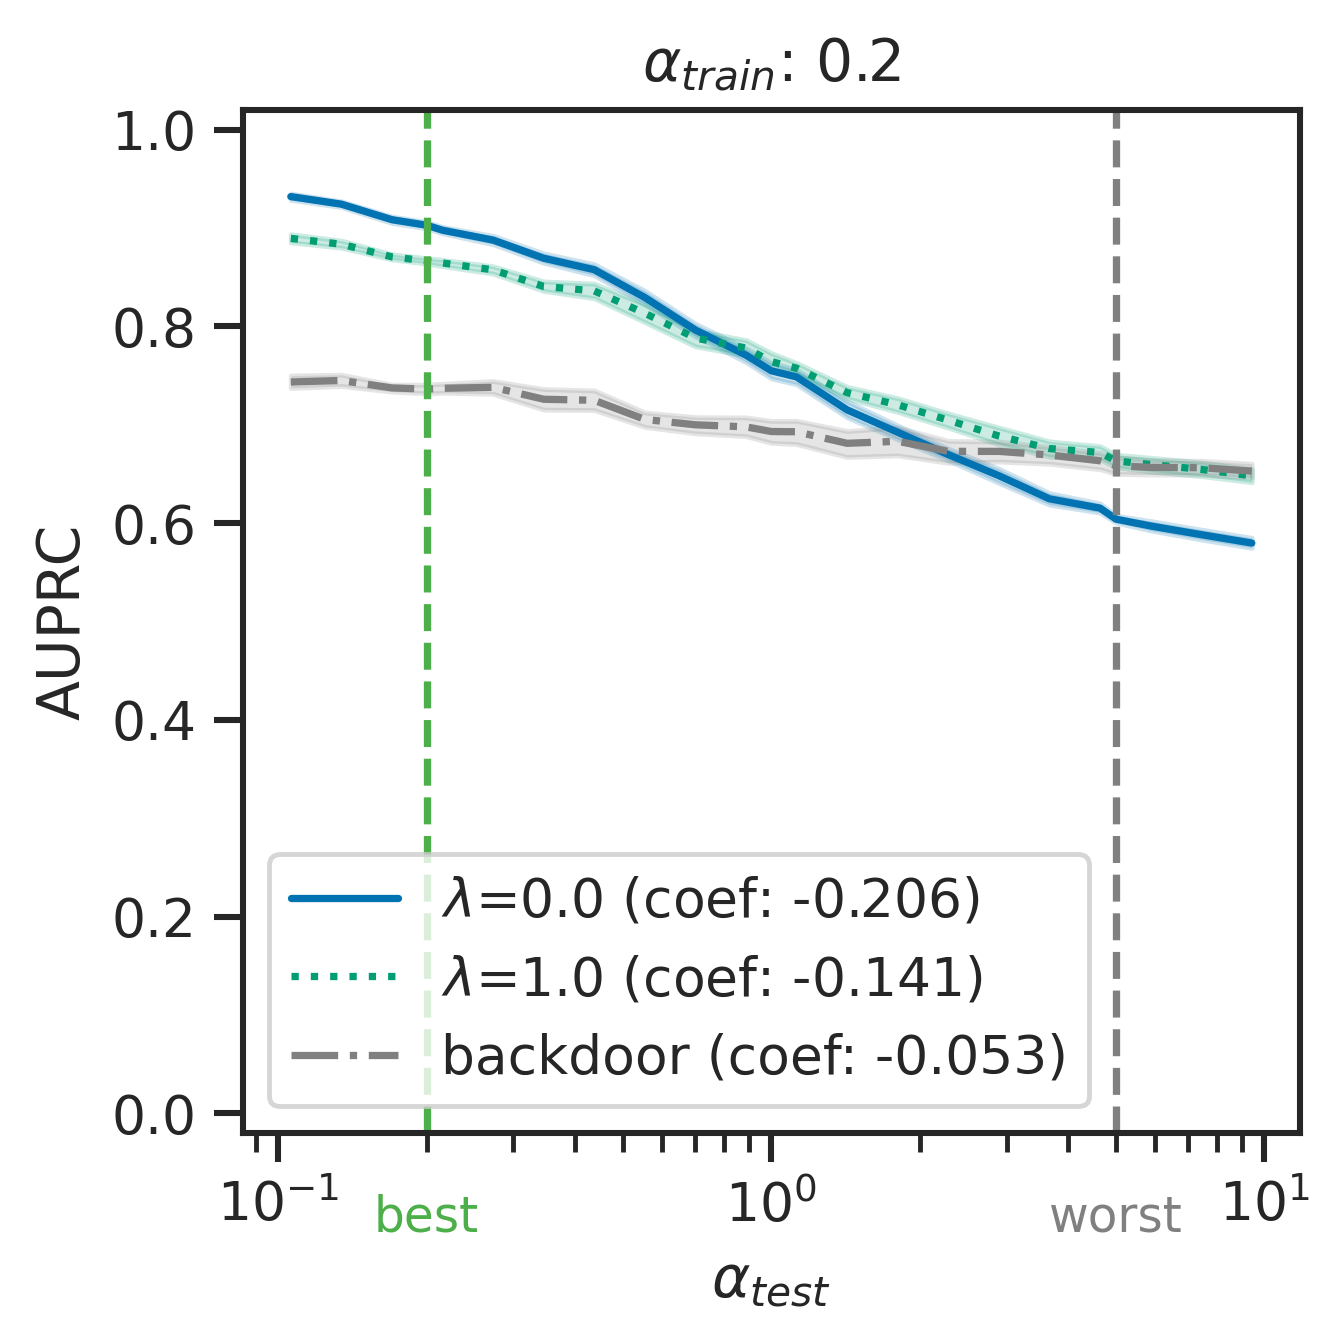

In [16]:
### DAPPER: Dominance-Aware Provenance Source/ReverseSource - One Plot - add backdoor

savefig = False
# savefig = True

my_palette = sns.color_palette("colorblind", 3)
my_linestyle = ['solid','dotted', 'dashdot']
xticks = [0.1,1,10]


outname = f"../output/TaskVectorFigs/fig_DA_{dataset_name}_{modelUsed}_Cz_0.5_Cy_0.5.png"


_df = deepcopy(df_eval)
_df_backdoor = deepcopy(df_eval_backdoor)

_df_backdoor = _df_backdoor.query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)



# _df['alpha_test'] = _df.apply(lambda x: 1/x['alpha_test'] if x['set'] in [566, 1152] else x['alpha_test'], axis=1)



if dataset_name in ["CD", "HateSpeech"]:
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 566)) | (_df["tv_direction"] == "ReverseSource") & (_df["set"] == 6621)].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)
elif dataset_name == "SHAC":
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 1152)) | (_df["tv_direction"] == "ReverseSource") & (_df["set"] == 11063)].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)

xname = "alpha_test"
ylabel = "auprc_weightsEdited"

# fig, ax = plt.subplots(1,1,figsize=(8,4), sharey=True)

fig, ax = plt.subplots(1,1,figsize=(4,4), sharey=True, squeeze=False)


for i, (set_i, alpha_train) in enumerate(zip(sets_reduce_ls, alpha_train_reduce_ls)):

    i=(0,0)
    if alpha_train == 0.2:
        
        df_sub = _df[_df['set'] == set_i]
        df_sub_backdoor = _df_backdoor[_df_backdoor['set'] == set_i]

        for ilambda, lambda_com in enumerate([0.0, 1.0]):
            c = my_palette[ilambda]

            if (set_i in [6621, 11063]) and (lambda_com == 1.0):
                c = my_palette[-1]

            _df_plt = df_sub[df_sub['lambda2'] == lambda_com].copy()
            reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))

            sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                         c=c, 
                         linestyle=my_linestyle[ilambda], label=r"$\lambda$=" +f"{lambda_com:.1f}" + f" (coef: {reg[0]:.3f})"
                        )


        reg_backdoor = get_coefLog10(x=list(df_sub_backdoor[xname]), y=list(df_sub_backdoor[ylabel]))
    
        sns.lineplot(data=df_sub_backdoor, x=xname, y=ylabel, ax=ax[i], 
                         c='grey', 
                         linestyle=my_linestyle[2], label=r"backdoor" + f" (coef: {reg_backdoor[0]:.3f})"
                        )
        ax[i].set_xscale('log')

        ax[i].axvline(set_alpha_train_DICT[set_i], color="#4DAF4A", linestyle='dashed')
        ax[i].axvline(1/set_alpha_train_DICT[set_i], color="grey", linestyle='dashed')
        ax[i].text(x=set_alpha_train_DICT[set_i], y=-0.12, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
        ax[i].text(x=1/set_alpha_train_DICT[set_i], y=-0.12, s='worst', color="grey", fontsize=10, horizontalalignment='center')


        ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
        ax[i].set_ylim((-0.02,1.02))
        ax[i].set_xticks(xticks)
        ax[i].legend(loc="lower left")
        ax[i].set_xlabel(r"$\alpha_{test}$")
        ax[i].set_ylabel("AUPRC")

        if set_i in [566, 1152]:
            ax[i].invert_xaxis()


plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

In [35]:
sns.color_palette("colorblind", 3)

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)]

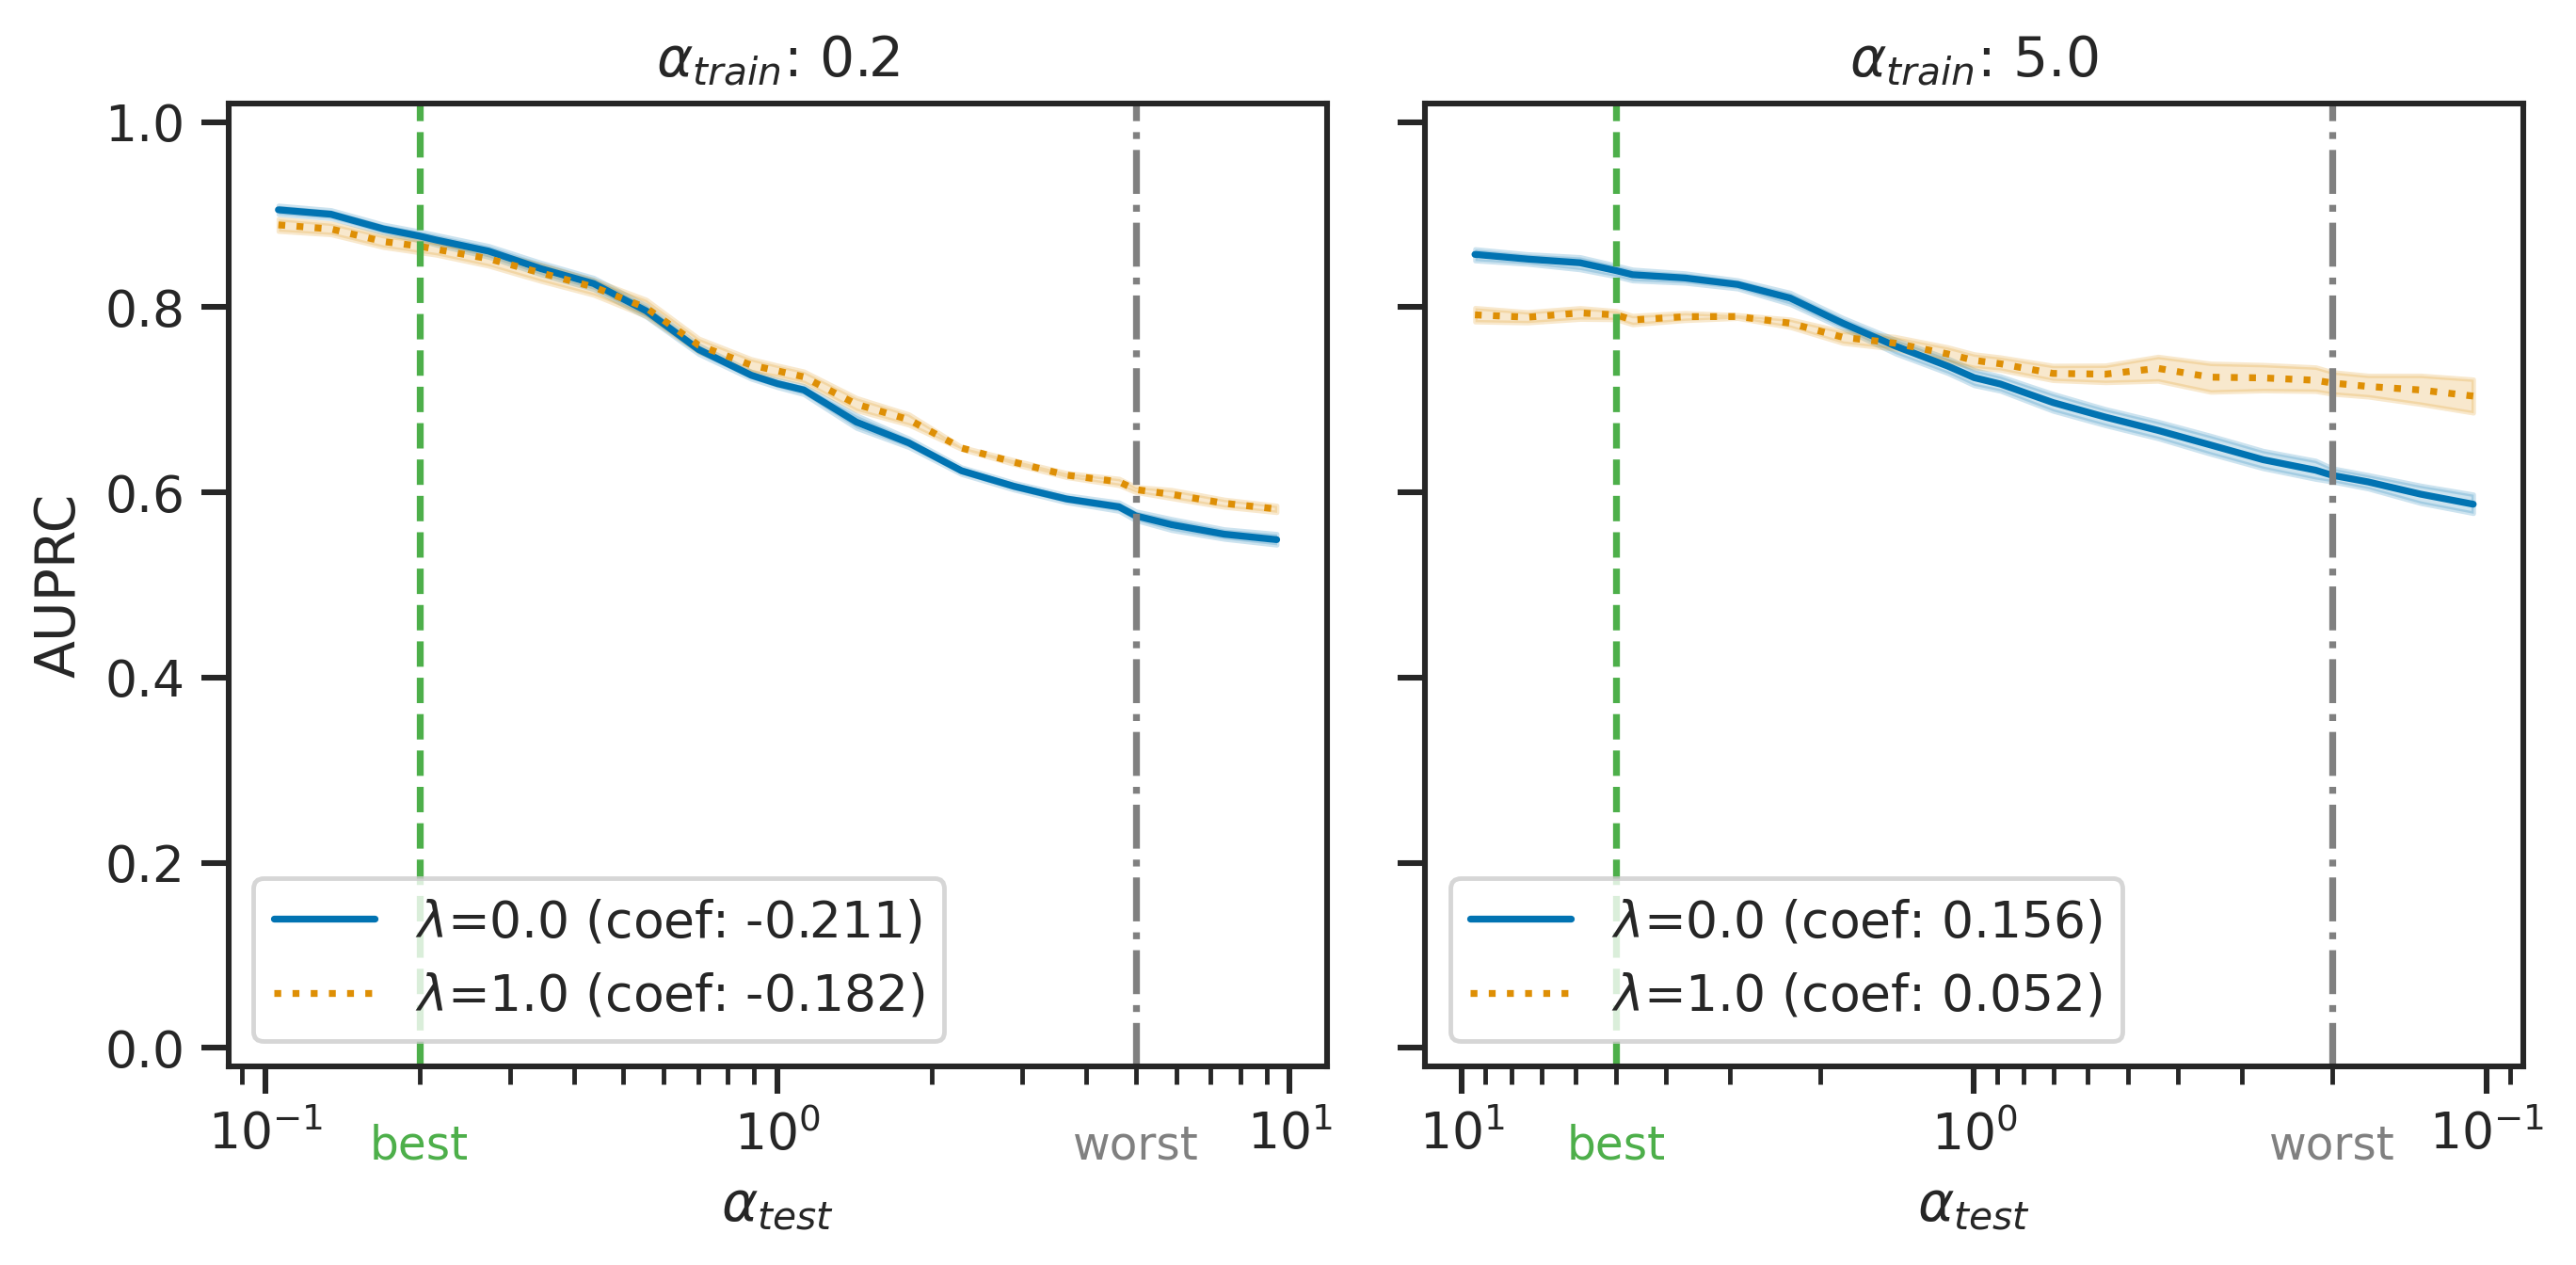

In [13]:
### All From Source - no backdoor - Two Plots

savefig = False
# savefig = True

my_palette = sns.color_palette("colorblind", 2)
my_linestyle = ['solid','dotted']
xticks = [0.1,1,10]

sr = "Source"
# sr = "ReverseSource"

outname = f"../output/TaskVectorFigs/fig_NoDAAllSource_{dataset_name}_{modelUsed}_{sr}_Cz_0.5_Cy_0.5.png"

_df = deepcopy(df_eval)

_df = _df[_df['tv_direction'] == sr].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)

# _df['alpha_test'] = _df.apply(lambda x: 1/x['alpha_test'] if x['set'] in [566, 1152] else x['alpha_test'], axis=1)


xname = "alpha_test"
ylabel = "auprc_weightsEdited"

fig, ax = plt.subplots(1,2, figsize=(8,4), sharey=True)



for i, (set_i, alpha_train) in enumerate(zip(sets_reduce_ls, alpha_train_reduce_ls)):
    df_sub = _df[_df['set'] == set_i]

    # for ilambda, lambda_com in enumerate(["1.0-0.0", "1.0-1.0"]):
    for ilambda, lambda_com in enumerate([0.0, 1.0]):
        
        # _df_plt = df_sub[df_sub['lambda1_lambda2'] == lambda_com].copy()
        _df_plt = df_sub[df_sub['lambda2'] == lambda_com].copy()

        reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))
        
        sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                     c=my_palette[ilambda], 
                     linestyle=my_linestyle[ilambda], label=r"$\lambda$=" +f"{lambda_com:.1f}" + f" (coef: {reg[0]:.3f})"
                    )
        

    ax[i].set_xscale('log')
    
    ax[i].axvline(set_alpha_train_DICT[set_i], color="#4DAF4A", linestyle='dashed')
    ax[i].axvline(1/set_alpha_train_DICT[set_i], color="grey", linestyle='dashdot')
    ax[i].text(x=set_alpha_train_DICT[set_i], y=-0.12, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
    ax[i].text(x=1/set_alpha_train_DICT[set_i], y=-0.12, s='worst', color="grey", fontsize=10, horizontalalignment='center')

    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((-0.02,1.02))
    ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")
    
    if set_i in [566, 1152]:
        ax[i].invert_xaxis()


plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

In [9]:
### Dominance-Aware Provenance Source/ReverseSource - One Plot - no backdoor

# savefig = False
savefig = True

my_palette = sns.color_palette("colorblind", 3)
my_linestyle = ['solid','dotted', 'dashdot']
xticks = [0.1,1,10]


outname = f"../output/TaskVectorFigs/fig_DA_{dataset_name}_{modelUsed}_Cz_0.5_Cy_0.5.png"


_df = deepcopy(df_eval)


# _df['alpha_test'] = _df.apply(lambda x: 1/x['alpha_test'] if x['set'] in [566, 1152] else x['alpha_test'], axis=1)



if dataset_name in ["CD", "HateSpeech"]:
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 566)) | (_df["tv_direction"] == "ReverseSource") & (_df["set"] == 6621)].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)
elif dataset_name == "SHAC":
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 1152)) | (_df["tv_direction"] == "ReverseSource") & (_df["set"] == 11063)].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)

xname = "alpha_test"
ylabel = "auprc_weightsEdited"

# fig, ax = plt.subplots(1,1,figsize=(8,4), sharey=True)

fig, ax = plt.subplots(1,1,figsize=(4,4), sharey=True, squeeze=False)


for i, (set_i, alpha_train) in enumerate(zip(sets_reduce_ls, alpha_train_reduce_ls)):

    i=(0,0)
    if alpha_train == 0.2:
        
        df_sub = _df[_df['set'] == set_i]

        for ilambda, lambda_com in enumerate([0.0, 1.0]):
            c = my_palette[ilambda]

            if (set_i in [6621, 11063]) and (lambda_com == 1.0):
                c = my_palette[-1]

            _df_plt = df_sub[df_sub['lambda2'] == lambda_com].copy()
            reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))

            sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                         c=c, 
                         linestyle=my_linestyle[ilambda], label=r"$\lambda$=" +f"{lambda_com:.1f}" + f" (coef: {reg[0]:.3f})"
                        )


        ax[i].set_xscale('log')

        ax[i].axvline(set_alpha_train_DICT[set_i], color="#4DAF4A", linestyle='dashed')
        ax[i].axvline(1/set_alpha_train_DICT[set_i], color="grey", linestyle='dashed')
        ax[i].text(x=set_alpha_train_DICT[set_i], y=-0.12, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
        ax[i].text(x=1/set_alpha_train_DICT[set_i], y=-0.12, s='worst', color="grey", fontsize=10, horizontalalignment='center')


        ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
        ax[i].set_ylim((-0.02,1.02))
        ax[i].set_xticks(xticks)
        ax[i].legend(loc="lower left")
        ax[i].set_xlabel(r"$\alpha_{test}$")
        ax[i].set_ylabel("AUPRC")

        if set_i in [566, 1152]:
            ax[i].invert_xaxis()


plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

In [ ]:
### Dominance-Aware Provenance Source/ReverseSource - Two plots... 0.2 vs 5

savefig = False
# savefig = True

my_palette = sns.color_palette("colorblind", 3)
my_linestyle = ['solid','dotted']
xticks = [0.1,1,10]


outname = f"../output/TaskVectorFigs/fig_DA_{dataset_name}_{modelUsed}_Cz_0.5_Cy_0.5.png"


_df = deepcopy(df_eval)


# _df['alpha_test'] = _df.apply(lambda x: 1/x['alpha_test'] if x['set'] in [566, 1152] else x['alpha_test'], axis=1)



if dataset_name in ["CD", "HateSpeech"]:
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 566)) | (_df["tv_direction"] == "ReverseSource") & (_df["set"] == 6621)].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)
elif dataset_name == "SHAC":
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 1152)) | (_df["tv_direction"] == "ReverseSource") & (_df["set"] == 11063)].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)

xname = "alpha_test"
ylabel = "auprc_weightsEdited"

# fig, ax = plt.subplots(1,1,figsize=(8,4), sharey=True)

fig, ax = plt.subplots(1,1,figsize=(4,4), sharey=True, squeeze=False)
i=(0,0)

for i, (set_i, alpha_train) in enumerate(zip(sets_reduce_ls, alpha_train_reduce_ls)):

        
    df_sub = _df[_df['set'] == set_i]

    for ilambda, lambda_com in enumerate([0.0, 1.0]):
        c = my_palette[ilambda]
        
        if (set_i in [6621, 11063]) and (lambda_com == 1.0):
            c = my_palette[-1]
            
        _df_plt = df_sub[df_sub['lambda2'] == lambda_com].copy()
        reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))
        
        sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                     c=c, 
                     linestyle=my_linestyle[ilambda], label=r"$\lambda$=" +f"{lambda_com:.1f}" + f" (coef: {reg[0]:.3f})"
                    )
        

    ax[i].set_xscale('log')
    
    ax[i].axvline(set_alpha_train_DICT[set_i], color="#4DAF4A", linestyle='dashed')
    ax[i].axvline(1/set_alpha_train_DICT[set_i], color="grey", linestyle='dashdot')
    ax[i].text(x=set_alpha_train_DICT[set_i], y=-0.12, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
    ax[i].text(x=1/set_alpha_train_DICT[set_i], y=-0.12, s='worst', color="grey", fontsize=10, horizontalalignment='center')
    

    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((-0.02,1.02))
    ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")
    
    if set_i in [566, 1152]:
        ax[i].invert_xaxis()


plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

# Task Vector: Base, Optimal, Estimate

In [2]:
sns.reset_defaults()
sns.set_theme(style="ticks", rc={"figure.dpi": 350})


In [3]:
import yaml


In [4]:
txt_DICT_lambda_configs = """
CD:
    RoBERTa:
        6621: 
            lambda2_sets: [0.0, 1.0, 1.0, 1.2]

        566:
            lambda2_sets: [0.0, 1.0, 1.2, 1.4]
    Llama:
        6621: 
            lambda2_sets: [0.0, 1.0, 0.4, 0.4]

        566:
            lambda2_sets: [0.0, 1.0, 0.4, 0.6]
            
    backdoor:
        6621:
            mean: 0.658407
            std: 0.029060
        566:
            mean: 0.741170
            std: 0.030391

    
            
HateSpeech:
    RoBERTa:
        6621:
            lambda2_sets: [0.0, 1.0, 1.0, 1.0]
        566:
            lambda2_sets: [0.0, 1.0, 1.0, 1.0]
    
    Llama:
        6621: 
            ##lambda2_sets: [0.0, 1.0, 1.4, 1.0]
            lambda2_sets: [0.0, 1.0, 0.4, 0.4]

        566:
            lambda2_sets: [0.0, 1.0, 0.4, 0.6]
            
    backdoor:
        6621:
            mean: 0.441861
            std: 0.019453
        566:
            mean: 0.456188
            std: 0.036991

SHAC:
    RoBERTa:
        11063:
            lambda2_sets: [0.0, 1.0, 1.2, 0.8]
        1152:
            lambda2_sets: [0.0, 1.0, 1.4, 1.2]
            
    Llama:
        11063: 
            ##lambda2_sets: [0.0, 1.0, 0.4, 0.4]
            lambda2_sets: [0.0, 1.0, 0.4, 0.2]

        1152:
            lambda2_sets: [0.0, 1.0, 0.6, 0.2]
            
    backdoor:
        11063:
            mean: 0.931327
            std: 0.004631
        1152:
            mean: 0.929287
            std: 0.019698
"""

set_name_ls = ['base','default', 'calculated', 'optimal']

DICT_lambda_configs = yaml.safe_load(txt_DICT_lambda_configs)

In [5]:
DICT_lambda_configs

{'CD': {'RoBERTa': {6621: {'lambda2_sets': [0.0, 1.0, 1.0, 1.2]},
   566: {'lambda2_sets': [0.0, 1.0, 1.2, 1.4]}},
  'Llama': {6621: {'lambda2_sets': [0.0, 1.0, 0.4, 0.4]},
   566: {'lambda2_sets': [0.0, 1.0, 0.4, 0.6]}},
  'backdoor': {6621: {'mean': 0.658407, 'std': 0.02906},
   566: {'mean': 0.74117, 'std': 0.030391}}},
 'HateSpeech': {'RoBERTa': {6621: {'lambda2_sets': [0.0, 1.0, 1.0, 1.0]},
   566: {'lambda2_sets': [0.0, 1.0, 1.0, 1.0]}},
  'Llama': {6621: {'lambda2_sets': [0.0, 1.0, 0.4, 0.4]},
   566: {'lambda2_sets': [0.0, 1.0, 0.4, 0.6]}},
  'backdoor': {6621: {'mean': 0.441861, 'std': 0.019453},
   566: {'mean': 0.456188, 'std': 0.036991}}},
 'SHAC': {'RoBERTa': {11063: {'lambda2_sets': [0.0, 1.0, 1.2, 0.8]},
   1152: {'lambda2_sets': [0.0, 1.0, 1.4, 1.2]}},
  'Llama': {11063: {'lambda2_sets': [0.0, 1.0, 0.4, 0.2]},
   1152: {'lambda2_sets': [0.0, 1.0, 0.6, 0.2]}},
  'backdoor': {11063: {'mean': 0.931327, 'std': 0.004631},
   1152: {'mean': 0.929287, 'std': 0.019698}}}}

## Print Summary

In [16]:
# # dataset_name = "CD"
# dataset_name = "HateSpeech"
# # modelUsed = "RoBERTa"
# modelUsed = "Llama"
# sets = [6621, 566]


dataset_name = "SHAC"
# modelUsed = "RoBERTa"
modelUsed = "Llama"
sets = [11063, 1152]

In [17]:
set_name_ls

['base', 'default', 'calculated', 'optimal']

In [18]:
df_ls = []



for set_i in sets:
    
    lambda2_sets = DICT_lambda_configs[dataset_name][modelUsed][set_i]['lambda2_sets']

    for lambda2, set_name in zip(lambda2_sets, set_name_ls):
        if modelUsed == "Llama":
            fname = "../output/tmpData/{}/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_{}-added-ntest_200-Runs_5.pkl"
            fname_reverse = "../output/tmpData/{}_ReverseSource/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_{}-added-ntest_200-Runs_5.pkl"

        elif modelUsed == "RoBERTa":
            fname = "../output/roberta/{}/Eval-set-{}-epoch3-lambda1_1.0-lambda2_{}-added-ntest_200-Runs_5.pkl"
            fname_reverse = "../output/roberta/{}_ReverseSource/Eval-set-{}-epoch3-lambda1_1.0-lambda2_{}-added-ntest_200-Runs_5.pkl"



        # for set_i in sets_ls:
        for nm in [fname, fname_reverse]:
            try:
                with open(nm.format(dataset_name, set_i, lambda2), "rb") as f:
                    df_tmp = pickle.load(file=f)

                df_tmp['set'] = set_i

                # if "lambda2_0.0" in nm:
                #     df_tmp["lambda1_lambda2"] = "1.0-0.0"
                #     df_tmp["lambda2"] = 0.0
                # elif "lambda2_1.0" in nm:
                #     df_tmp["lambda1_lambda2"] = "1.0-1.0"
                #     df_tmp["lambda2"] = 1.0

                df_tmp["lambda2"] = lambda2

                if "Reverse" in nm:
                    df_tmp['tv_direction'] = 'ReverseSource'
                else:
                    df_tmp['tv_direction'] = 'Source'

                df_tmp['set_name'] = set_name



                df_ls.append(df_tmp)
                del df_tmp
            except Exception as e:
                print(e)
            
df_eval = pd.concat(df_ls).reset_index(drop=True)    


In [46]:
#### For TAPER Results!! --- Only base+default


_df = deepcopy(df_eval)

# _df['alpha_test'] = _df.apply(lambda x: 1/x['alpha_test'] if x['set'] in [566, 1152] else x['alpha_test'], axis=1)



if dataset_name in ["CD", "HateSpeech"]:
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 566)) | ((_df["tv_direction"] == "Source") & (_df["set"] == 6621))].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)
elif dataset_name == "SHAC":
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 1152)) | ((_df["tv_direction"] == "Source") & (_df["set"] == 11063))].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)

xname = "alpha_test"
ylabel = "auprc_weightsEdited"



for i, set_i in enumerate(sets):
    alpha_train = set_alpha_train_DICT[set_i]
    df_sub = _df[_df['set'] == set_i]

    for ilambda, (lambda_com, set_name) in enumerate(zip(lambda2_sets, set_name_ls)):
        if set_name not in ['base', 'default']:
            continue
        # c = my_palette[set_name]

        # if (set_i in [6621, 11063]) and (lambda_com == 1.0):
        #     c = my_palette[-1]

        # _df_plt = df_sub[df_sub['lambda2'] == lambda_com].copy()
        _df_plt = df_sub[df_sub['set_name'] == set_name].copy()
        
        
        print(set_i)
        print(set_name)
        ttt = _df_plt[_df_plt['alpha_test'] == 1/alpha_train][ylabel].describe() 
        print(ttt)
        print(f"{ttt['mean']:.3f} + {ttt['std']:.3f}")
        print("\n\n")
        


6621
base
count    45.000000
mean      0.756410
std       0.044462
min       0.685146
25%       0.745628
50%       0.749950
75%       0.784668
max       0.816655
Name: auprc_weightsEdited, dtype: float64
0.756 + 0.044



6621
default
count    45.000000
mean      0.462477
std       0.013904
min       0.448487
25%       0.451591
50%       0.454308
75%       0.475987
max       0.482012
Name: auprc_weightsEdited, dtype: float64
0.462 + 0.014



566
base
count    45.000000
mean      0.682833
std       0.013904
min       0.667701
25%       0.668824
50%       0.681713
75%       0.692452
max       0.703476
Name: auprc_weightsEdited, dtype: float64
0.683 + 0.014



566
default
count    45.000000
mean      0.813060
std       0.021314
min       0.788316
25%       0.790872
50%       0.813081
75%       0.833694
max       0.839340
Name: auprc_weightsEdited, dtype: float64
0.813 + 0.021





In [ ]:
#### For DAPPER Results!! -- Print Summary


_df = deepcopy(df_eval)

_df["C_y"] = _df["C_y"].round(2)

# _df['alpha_test'] = _df.apply(lambda x: 1/x['alpha_test'] if x['set'] in [566, 1152] else x['alpha_test'], axis=1)



if dataset_name in ["CD", "HateSpeech"]:
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 566)) | ((_df["tv_direction"] == "ReverseSource") & (_df["set"] == 6621))].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)
elif dataset_name == "SHAC":
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 1152)) | ((_df["tv_direction"] == "ReverseSource") & (_df["set"] == 11063))].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)

xname = "alpha_test"
ylabel = "auprc_weightsEdited"



for i, set_i in enumerate(sets):
    alpha_train = set_alpha_train_DICT[set_i]
    df_sub = _df[_df['set'] == set_i]

    for ilambda, (lambda_com, set_name) in enumerate(zip(lambda2_sets, set_name_ls)):
        # c = my_palette[set_name]

        # if (set_i in [6621, 11063]) and (lambda_com == 1.0):
        #     c = my_palette[-1]

        # _df_plt = df_sub[df_sub['lambda2'] == lambda_com].copy()
        _df_plt = df_sub[df_sub['set_name'] == set_name].copy()
        
        print(_df_plt.groupby(['set', 'set_name', 'tv_direction', 'lambda2']).size())
        print(set_i)
        print(set_name)
        
        ttt = _df_plt[_df_plt['alpha_test'] == 1/alpha_train][ylabel].describe() 
        print(ttt)
        print(f"{ttt['mean']:.3f} + {ttt['std']:.3f}")
        

        print("\n\n")
        


In [58]:
df_eval.groupby(['set','set_name', 'tv_direction','lambda2']).size()

set   set_name    tv_direction   lambda2
566   base        ReverseSource  0.0        30285
                  Source         0.0        30285
      calculated  ReverseSource  1.2        30285
                  Source         1.2        30285
      default     ReverseSource  1.0        30285
                  Source         1.0        30285
      optimal     ReverseSource  1.4        30285
                  Source         1.4        30285
6621  base        ReverseSource  0.0        30285
                  Source         0.0        30285
      calculated  ReverseSource  1.0        30285
                  Source         1.0        30285
      default     ReverseSource  1.0        30285
                  Source         1.0        30285
      optimal     ReverseSource  1.2        30285
                  Source         1.2        30285
dtype: int64

In [49]:
#### For DAPPER Results!! -- Print Summary


_df = deepcopy(df_eval)


# _df['alpha_test'] = _df.apply(lambda x: 1/x['alpha_test'] if x['set'] in [566, 1152] else x['alpha_test'], axis=1)



if dataset_name in ["CD", "HateSpeech"]:
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 566)) | ((_df["tv_direction"] == "ReverseSource") & (_df["set"] == 6621))].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)
elif dataset_name == "SHAC":
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 1152)) | ((_df["tv_direction"] == "ReverseSource") & (_df["set"] == 11063))].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)

In [50]:
_df.groupby(['set','set_name', 'tv_direction','lambda2']).size()

set   set_name    tv_direction   lambda2
566   base        Source         0.0        1035
      calculated  Source         1.2        1035
      default     Source         1.0        1035
      optimal     Source         1.4        1035
6621  base        ReverseSource  0.0        1035
      calculated  ReverseSource  1.0        1035
      default     ReverseSource  1.0        1035
      optimal     ReverseSource  1.2        1035
dtype: int64

In [51]:
xname = "alpha_test"
ylabel = "auprc_weightsEdited"

for i, set_i in enumerate(sets):
    alpha_train = set_alpha_train_DICT[set_i]
    df_sub = _df[_df['set'] == set_i]

    for ilambda, (lambda_com, set_name) in enumerate(zip(lambda2_sets, set_name_ls)):
        # c = my_palette[set_name]

        # if (set_i in [6621, 11063]) and (lambda_com == 1.0):
        #     c = my_palette[-1]

        # _df_plt = df_sub[df_sub['lambda2'] == lambda_com].copy()
        _df_plt = df_sub[df_sub['set_name'] == set_name].copy()
        
        print(_df_plt.groupby(['set', 'set_name', 'tv_direction', 'lambda2']).size())
        print(set_i)
        print(set_name)
        
        ttt = _df_plt[_df_plt['alpha_test'] == 1/alpha_train][ylabel].describe() 
        print(ttt)
        print(f"{ttt['mean']:.3f} + {ttt['std']:.3f}")
        

        print("\n\n")
        

set   set_name  tv_direction   lambda2
6621  base      ReverseSource  0.0        1035
dtype: int64
6621
base
count    45.000000
mean      0.574745
std       0.017755
min       0.555610
25%       0.558683
50%       0.572089
75%       0.583833
max       0.603510
Name: auprc_weightsEdited, dtype: float64
0.575 + 0.018



set   set_name  tv_direction   lambda2
6621  default   ReverseSource  1.0        1035
dtype: int64
6621
default
count    45.000000
mean      0.613535
std       0.015472
min       0.588257
25%       0.607822
50%       0.615779
75%       0.621563
max       0.634252
Name: auprc_weightsEdited, dtype: float64
0.614 + 0.015



set   set_name    tv_direction   lambda2
6621  calculated  ReverseSource  1.0        1035
dtype: int64
6621
calculated
count    45.000000
mean      0.613535
std       0.015472
min       0.588257
25%       0.607822
50%       0.615779
75%       0.621563
max       0.634252
Name: auprc_weightsEdited, dtype: float64
0.614 + 0.015



set   set_name  tv_directio

## Plot together

6621
base
count    45.000000
mean      0.604048
std       0.013193
min       0.584793
25%       0.598144
50%       0.603168
75%       0.609806
max       0.624331
Name: auprc_weightsEdited, dtype: float64



6621
default
count    45.000000
mean      0.663265
std       0.022438
min       0.627543
25%       0.654145
50%       0.664814
75%       0.675890
max       0.693931
Name: auprc_weightsEdited, dtype: float64



[5.]
6621
calculated
count    45.000000
mean      0.645038
std       0.017775
min       0.619760
25%       0.637167
50%       0.638248
75%       0.664759
max       0.665255
Name: auprc_weightsEdited, dtype: float64



[5.]
6621
optimal
count    45.000000
mean      0.663265
std       0.022438
min       0.627543
25%       0.654145
50%       0.664814
75%       0.675890
max       0.693931
Name: auprc_weightsEdited, dtype: float64



566
base
count    45.000000
mean      0.659037
std       0.045445
min       0.617511
25%       0.623207
50%       0.627045
75%       0.707131
max     

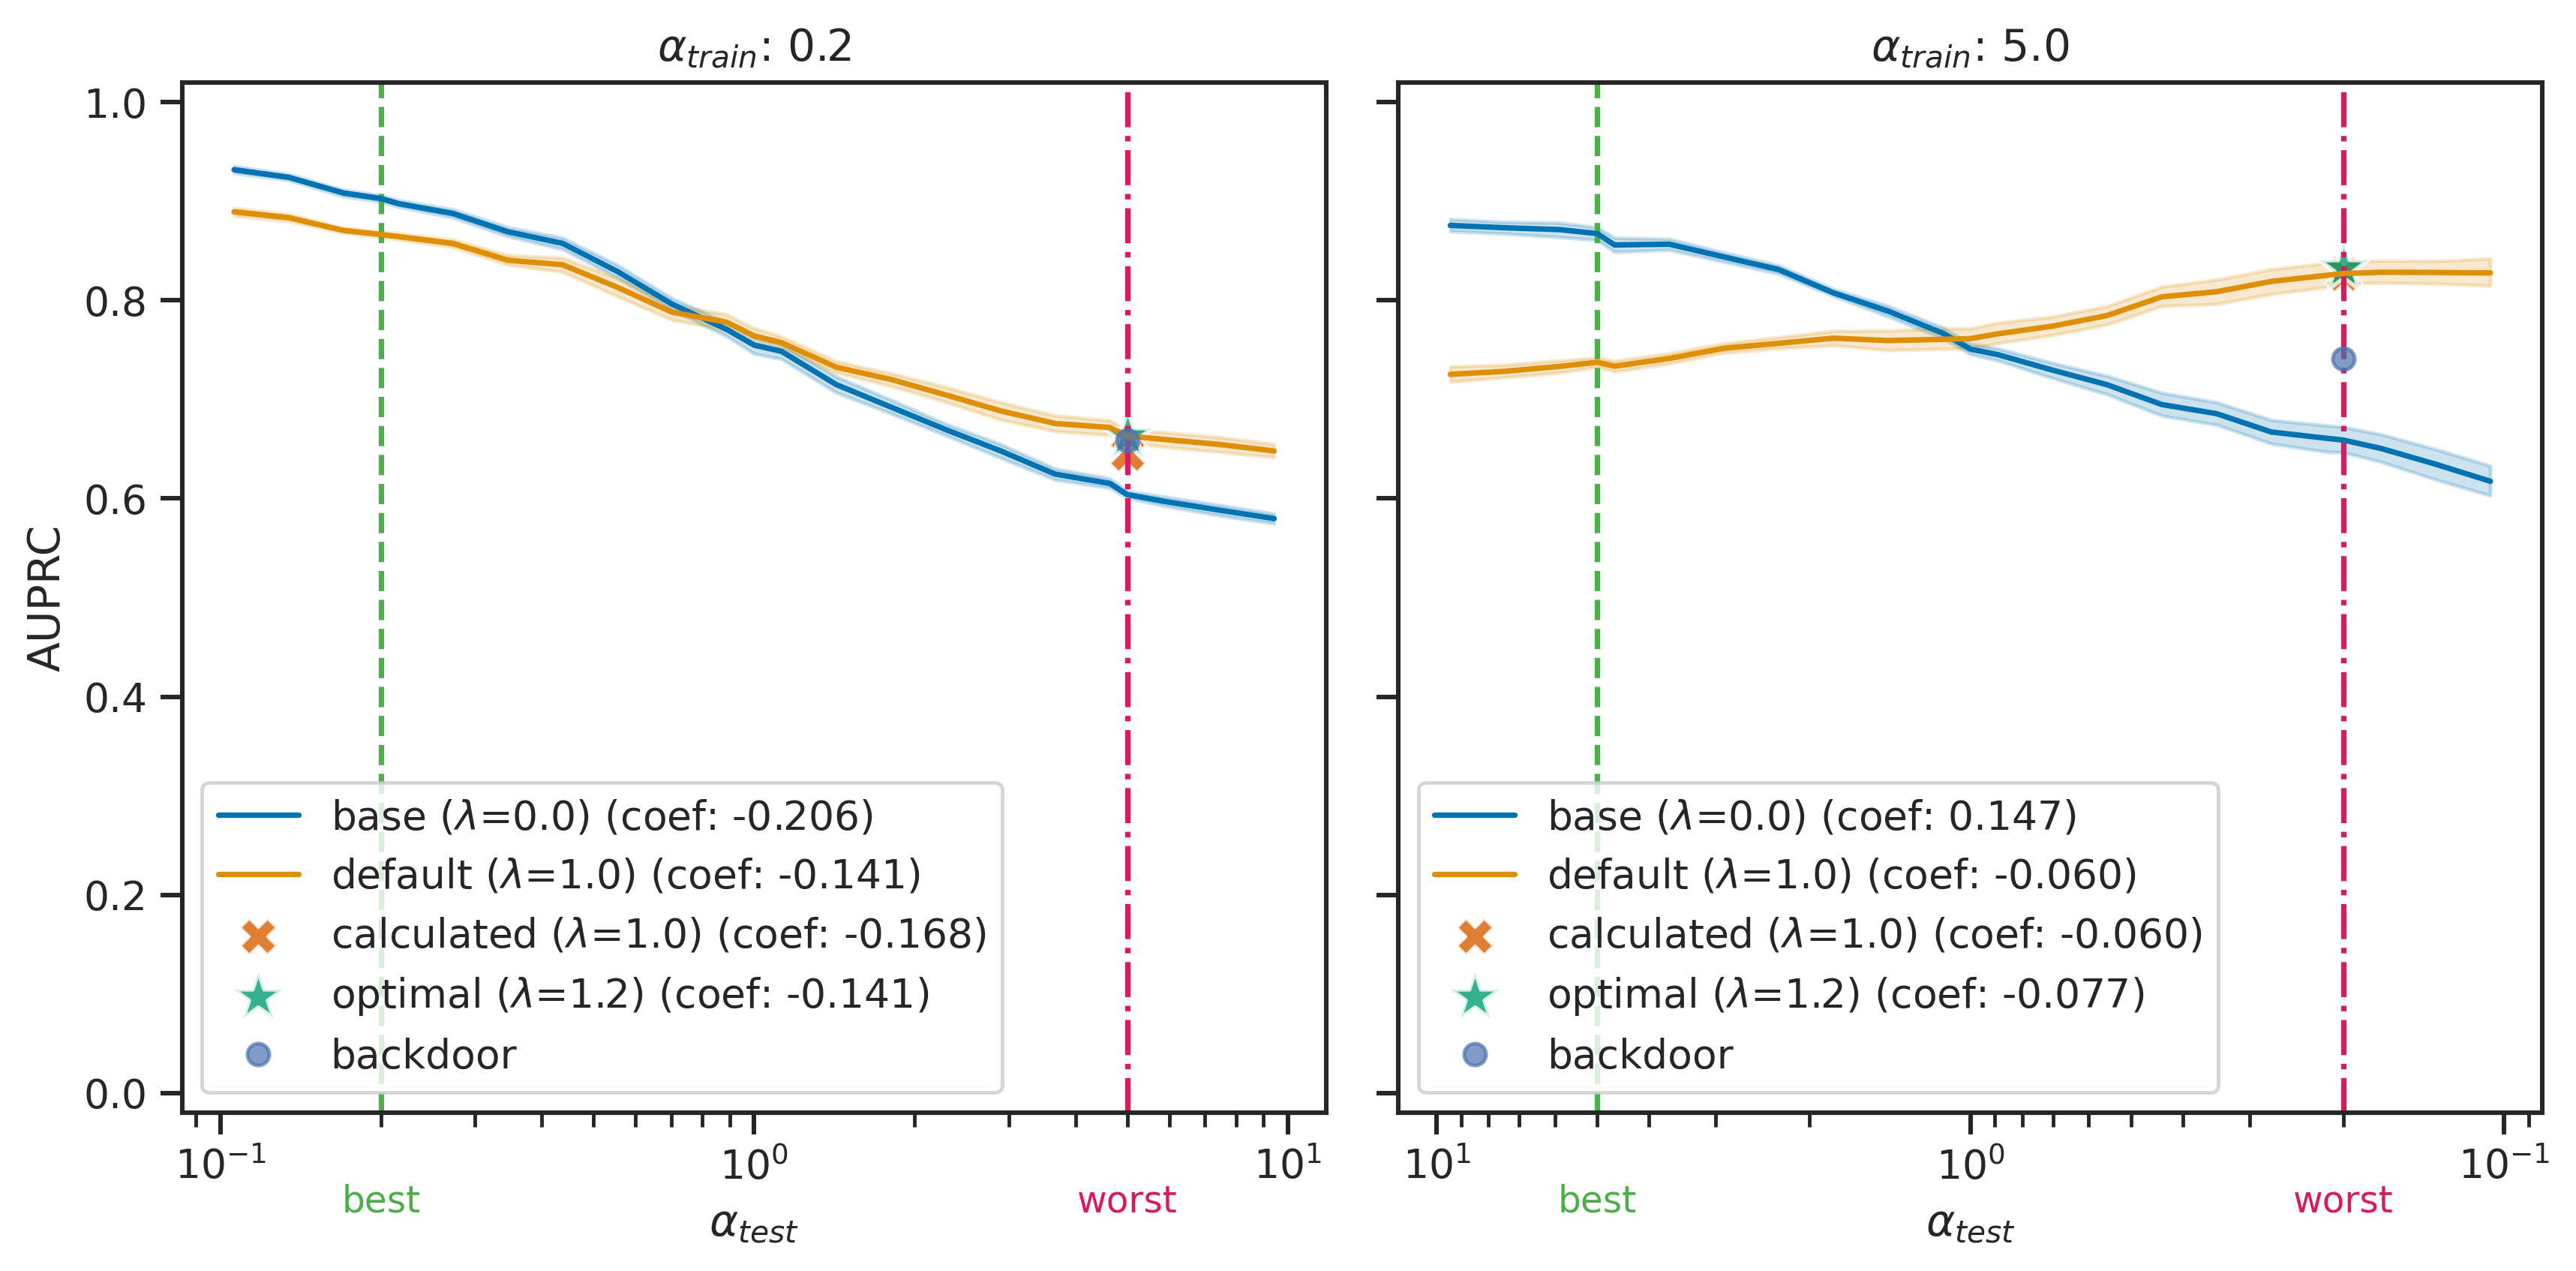

In [10]:
### DAPPER: Dominance-Aware Provenance Source/ReverseSource - Combined Plot (0.2 + 5)

savefig = False
# savefig = True

my_palette_full = sns.color_palette("colorblind", 5)

my_palette = {"base": my_palette_full[0], "default":my_palette_full[1], "optimal": my_palette_full[2], "calculated":my_palette_full[3]}
my_linestyle = ['solid','dotted']
my_linestyle = ['solid'] * 5

marker_style = {"optimal":"*", "calculated": "X"}
size_style = {"optimal":200, "calculated": 100}

xticks = [0.1,1,10]


outname = f"../output/TaskVectorFigs/fig_BaseOptimalEstimate_{dataset_name}_{modelUsed}_Cz_0.5_Cy_0.5.png"


_df = deepcopy(df_eval)


# _df['alpha_test'] = _df.apply(lambda x: 1/x['alpha_test'] if x['set'] in [566, 1152] else x['alpha_test'], axis=1)



if dataset_name in ["CD", "HateSpeech"]:
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 566)) | ((_df["tv_direction"] == "ReverseSource") & (_df["set"] == 6621))].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)
elif dataset_name == "SHAC":
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 1152)) | ((_df["tv_direction"] == "ReverseSource") & (_df["set"] == 11063))].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)

xname = "alpha_test"
ylabel = "auprc_weightsEdited"


fig, ax = plt.subplots(1,2,figsize=(10,5), sharey=True)

for i, set_i in enumerate(sets):


    


    ax[i].axvline(set_alpha_train_DICT[set_i], color="#4DAF4A", linestyle='dashed')
    ax[i].axvline(1/set_alpha_train_DICT[set_i], color="#D81B60", linestyle='dashdot')
    ax[i].text(x=set_alpha_train_DICT[set_i], y=-0.12, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
    ax[i].text(x=1/set_alpha_train_DICT[set_i], y=-0.12, s='worst', color="#D81B60", fontsize=10, horizontalalignment='center')



    alpha_train = set_alpha_train_DICT[set_i]
    df_sub = _df[_df['set'] == set_i]

    for ilambda, (lambda_com, set_name) in enumerate(zip(lambda2_sets, set_name_ls)):
        c = my_palette[set_name]

        # if (set_i in [6621, 11063]) and (lambda_com == 1.0):
        #     c = my_palette[-1]

        # _df_plt = df_sub[df_sub['lambda2'] == lambda_com].copy()
        _df_plt = df_sub[df_sub['set_name'] == set_name].copy()


        reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))

        set_name_i = _df_plt['set_name'].unique()

        assert len(set_name_i) == 1
        assert set_name_i[0] == set_name

        if set_name in ['base', 'default']:
            sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                         c=c, 
                         linestyle=my_linestyle[ilambda], label=f"{set_name} " + r"($\lambda$=" +f"{lambda_com:.1f})" + f" (coef: {reg[0]:.3f})"
                        )
        else:
            print(_df_plt[_df_plt['alpha_test'] == 1/alpha_train][xname].unique())
            _df_box = _df_plt[_df_plt['alpha_test'] == 1/alpha_train]

            sns.scatterplot(x=[_df_box[xname].mean()], y=[_df_box[ylabel].mean()], ax=ax[i], 
                            c=c, marker=marker_style[set_name], 
                            s=size_style[set_name], alpha=0.8,
                            label=f"{set_name} " + r"($\lambda$=" +f"{lambda_com:.1f})" + f" (coef: {reg[0]:.3f})")
            # ax[i].boxplot(_df_box[ylabel], positions=[1/alpha_train_i])


            
        print(set_i)
        print(set_name)
        print(_df_plt[_df_plt['alpha_test'] == 1/alpha_train][ylabel].describe() )
        print("\n\n")
        
    # sns.scatterplot(x=[1/alpha_train], y=[DICT_lambda_configs[dataset_name]['backdoor'][set_i]['mean']], label="backdoor", ax=ax[i])
    
    # y_backdoor_std = DICT_lambda_configs[dataset_name]['backdoor'][set_i]['std']
    # ax[i].errorbar(1/alpha_train, y_backdoor_mean, yerr=y_backdoor_std, fmt='o', label="backdoor")
    y_backdoor_mean = DICT_lambda_configs[dataset_name]['backdoor'][set_i]['mean']
    ax[i].errorbar(1/alpha_train, y_backdoor_mean, fmt='o', label="backdoor", alpha=0.7)
    
    
    
    ax[i].set_xscale('log')


    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((-0.02,1.02))
    ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")

    if set_i in [566, 1152]:
        ax[i].invert_xaxis()


plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()



## Plot separately..

In [2]:
sns.reset_defaults()
sns.set_theme(style="ticks", rc={"figure.dpi": 100})


In [121]:
alpha_train_i = 0.2

# dataset_name = 'CD'
# set_i = 6621
# modelUsed = "RoBERTa"
# ## lambda2_sets = [0.0, 1.0, 1.0, 0.6] # base, default, optimal, calculated  # arbitrary optimal, max
# lambda2_sets = [0.0, 1.0, 0.4, 1.0] # base, default, calculated, optimal  # optimal: best worst-case AUPRC, mean

# dataset_name = 'HateSpeech'
# set_i = 6621
# modelUsed = "RoBERTa"
# # lambda2_sets = [0.0, 1.0, 0.6, 1.0] # base, default, optimal, calculated
# lambda2_sets = [0.0, 1.0, 0.6, 0.6] # base, default, calculated, optimal  # optimal: best worst-case AUPRC, mean


dataset_name = 'SHAC'
set_i = 11063
modelUsed = "RoBERTa"
# lambda2_sets = [0.0, 1.0, 0.0, 1.0] # base, default, optimal, calculated
lambda2_sets = [0.0, 1.0, 0.8, 0.0] # base, default, calculated, optimal  # optimal: best worst-case AUPRC, mean

set_name_ls = ['base','default', 'calculated', 'optimal']

In [130]:
alpha_train_i = 5

# dataset_name = 'CD'
# set_i = 566
# modelUsed = "RoBERTa"
# ## lambda2_sets = [0.0, 1.0, 0.8, 1.0] # base, default, optimal, calculated
# lambda2_sets = [0.0, 1.0, 1.0, 1.2] # base, default, calculated, optimal  # optimal: best worst-case AUPRC, mean

# dataset_name = 'HateSpeech'
# set_i = 566
# modelUsed = "RoBERTa"
# # lambda2_sets = [0.0, 1.0, 1.0, 0.8] # base, default, optimal, calculated
# lambda2_sets = [0.0, 1.0, 1.0, 1.2] # base, default, calculated, optimal  # optimal: best worst-case AUPRC, mean


dataset_name = 'SHAC'
set_i = 1152
modelUsed = "RoBERTa"
# lambda2_sets = [0.0, 1.0, 0.6, 1.0] # base, default, optimal, calculated
lambda2_sets = [0.0, 1.0, 1.2, 0.6] # base, default, calculated, optimal  # optimal: best worst-case AUPRC, mean


set_name_ls = ['base','default', 'calculated', 'optimal']

In [166]:
alpha_train_i = 0.2

# dataset_name = 'CD'
# set_i = 6621
# modelUsed = "Llama"
# # lambda2_sets = [0.0, 1.0, 0.2, 0.4] # base, default, optimal, calculated
# lambda2_sets = [0.0, 1.0, 0.4, 0.4] # base, default, calculated, optimal  # optimal: best worst-case AUPRC, mean

# dataset_name = 'HateSpeech'
# set_i = 6621
# modelUsed = "Llama"
# ## lambda2_sets = [0.0, 1.0, 0.4, 0.2] # base, default, optimal, calculated
# lambda2_sets = [0.0, 1.0, 0.4, 0.4] # base, default, calculated, optimal  # optimal: best worst-case AUPRC, mean


dataset_name = 'SHAC'
set_i = 11063
modelUsed = "Llama"
# lambda2_sets = [0.0, 1.0, 0.2, 0.4] # base, default, optimal, calculated
lambda2_sets = [0.0, 1.0, 0.4, 0.2] # base, default, calculated, optimal  # optimal: best worst-case AUPRC, mean

set_name_ls = ['base','default', 'calculated', 'optimal']

In [175]:
alpha_train_i = 5

dataset_name = 'CD'
set_i = 566
modelUsed = "Llama"
# lambda2_sets = [0.0, 1.0, 0.2, 0.4] # base, default, optimal, calculated
lambda2_sets = [0.0, 1.0, 0.4, 0.6] # base, default, calculated, optimal  # optimal: best worst-case AUPRC, mean

# dataset_name = 'HateSpeech'
# set_i = 566
# modelUsed = "Llama"
# ## lambda2_sets = [0.0, 1.0, 0.2, 0.4] # base, default, optimal, calculated
# lambda2_sets = [0.0, 1.0, 0.4, 0.6] # base, default, calculated, optimal  # optimal: best worst-case AUPRC, mean


# dataset_name = 'SHAC'
# set_i = 1152
# modelUsed = "Llama"
# # lambda2_sets = [0.0, 1.0, 0.4, 0.2] # base, default, optimal, calculated
# lambda2_sets = [0.0, 1.0, 0.6, 0.2] # base, default, calculated, optimal  # optimal: best worst-case AUPRC, mean

set_name_ls = ['base','default', 'calculated', 'optimal']

In [176]:
df_ls = []

for lambda2, set_name in zip(lambda2_sets, set_name_ls):
    if modelUsed == "Llama":
        fname = "../output/tmpData/{}/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_{}-added-ntest_200-Runs_5.pkl"
        fname_reverse = "../output/tmpData/{}_ReverseSource/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_{}-added-ntest_200-Runs_5.pkl"

    elif modelUsed == "RoBERTa":
        fname = "../output/roberta/{}/Eval-set-{}-epoch3-lambda1_1.0-lambda2_{}-added-ntest_200-Runs_5.pkl"
        fname_reverse = "../output/roberta/{}_ReverseSource/Eval-set-{}-epoch3-lambda1_1.0-lambda2_{}-added-ntest_200-Runs_5.pkl"
    


    # for set_i in sets_ls:
    for nm in [fname, fname_reverse]:
        try:
            with open(nm.format(dataset_name, set_i, lambda2), "rb") as f:
                df_tmp = pickle.load(file=f)

            df_tmp['set'] = set_i

            # if "lambda2_0.0" in nm:
            #     df_tmp["lambda1_lambda2"] = "1.0-0.0"
            #     df_tmp["lambda2"] = 0.0
            # elif "lambda2_1.0" in nm:
            #     df_tmp["lambda1_lambda2"] = "1.0-1.0"
            #     df_tmp["lambda2"] = 1.0

            df_tmp["lambda2"] = lambda2

            if "Reverse" in nm:
                df_tmp['tv_direction'] = 'ReverseSource'
            else:
                df_tmp['tv_direction'] = 'Source'

            df_tmp['set_name'] = set_name

            df_ls.append(df_tmp)
            del df_tmp
        except Exception as e:
            print(e)
            
df_eval = pd.concat(df_ls).reset_index(drop=True)    


[0.2]
[0.2]


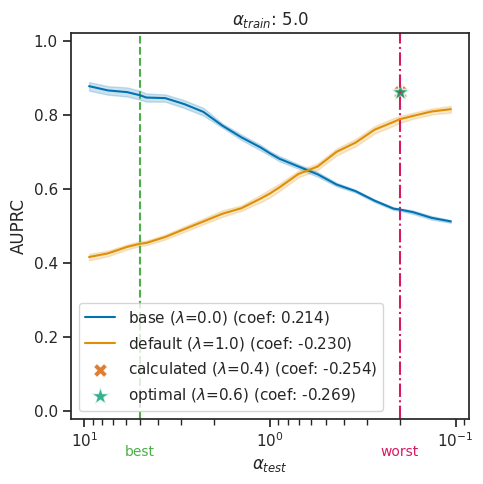

In [177]:
### Dominance-Aware Provenance Source/ReverseSource - separate plot

savefig = False
# savefig = True

my_palette_full = sns.color_palette("colorblind", 5)

my_palette = {"base": my_palette_full[0], "default":my_palette_full[1], "optimal": my_palette_full[2], "calculated":my_palette_full[3]}
my_linestyle = ['solid','dotted']
my_linestyle = ['solid'] * 5

marker_style = {"optimal":"*", "calculated": "X"}
size_style = {"optimal":200, "calculated": 100}

xticks = [0.1,1,10]


outname = f"../output/TaskVectorFigs/xxxxxxxfig_DA_{dataset_name}_{modelUsed}_Cz_0.5_Cy_0.5.png"


_df = deepcopy(df_eval)


# _df['alpha_test'] = _df.apply(lambda x: 1/x['alpha_test'] if x['set'] in [566, 1152] else x['alpha_test'], axis=1)



if dataset_name in ["CD", "HateSpeech"]:
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 566)) | ((_df["tv_direction"] == "ReverseSource") & (_df["set"] == 6621))].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)
elif dataset_name == "SHAC":
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 1152)) | ((_df["tv_direction"] == "ReverseSource") & (_df["set"] == 11063))].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)

xname = "alpha_test"
ylabel = "auprc_weightsEdited"


fig, ax = plt.subplots(1,1,figsize=(5,5), sharey=True, squeeze=False)
i=(0,0)


ax[i].axvline(set_alpha_train_DICT[set_i], color="#4DAF4A", linestyle='dashed')
ax[i].axvline(1/set_alpha_train_DICT[set_i], color="#D81B60", linestyle='dashdot')
ax[i].text(x=set_alpha_train_DICT[set_i], y=-0.12, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
ax[i].text(x=1/set_alpha_train_DICT[set_i], y=-0.12, s='worst', color="#D81B60", fontsize=10, horizontalalignment='center')



alpha_train = alpha_train_i    
df_sub = _df[_df['set'] == set_i]

for ilambda, (lambda_com, set_name) in enumerate(zip(lambda2_sets, set_name_ls)):
    c = my_palette[set_name]

    # if (set_i in [6621, 11063]) and (lambda_com == 1.0):
    #     c = my_palette[-1]

    # _df_plt = df_sub[df_sub['lambda2'] == lambda_com].copy()
    _df_plt = df_sub[df_sub['set_name'] == set_name].copy()
    
    
    reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))

    set_name_i = _df_plt['set_name'].unique()

    assert len(set_name_i) == 1
    assert set_name_i[0] == set_name

    if set_name in ['base', 'default']:
        sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                     c=c, 
                     linestyle=my_linestyle[ilambda], label=f"{set_name} " + r"($\lambda$=" +f"{lambda_com:.1f})" + f" (coef: {reg[0]:.3f})"
                    )
    else:
        print(_df_plt[_df_plt['alpha_test'] == 1/alpha_train_i][xname].unique())
        _df_box = _df_plt[_df_plt['alpha_test'] == 1/alpha_train_i]
        
        sns.scatterplot(x=[_df_box[xname].mean()], y=[_df_box[ylabel].mean()], ax=ax[i], 
                        c=c, marker=marker_style[set_name], 
                        s=size_style[set_name], alpha=0.8,
                        label=f"{set_name} " + r"($\lambda$=" +f"{lambda_com:.1f})" + f" (coef: {reg[0]:.3f})")
        # ax[i].boxplot(_df_box[ylabel], positions=[1/alpha_train_i])
        


ax[i].set_xscale('log')


ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
ax[i].set_ylim((-0.02,1.02))
ax[i].set_xticks(xticks)
ax[i].legend(loc="lower left")
ax[i].set_xlabel(r"$\alpha_{test}$")
ax[i].set_ylabel("AUPRC")

if set_i in [566, 1152]:
    ax[i].invert_xaxis()


plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()



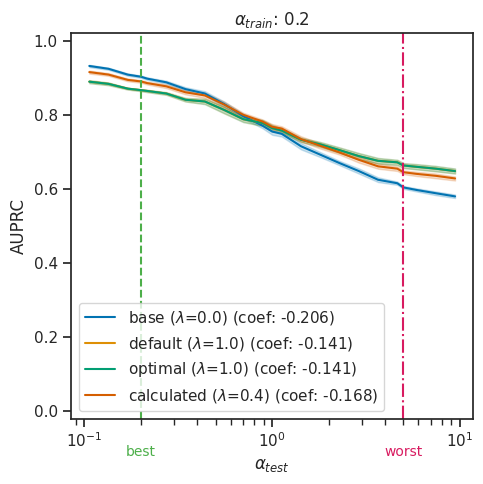

In [34]:
### Plot All 4 lines....
### Dominance-Aware Provenance Source/ReverseSource

savefig = False
# savefig = True

my_palette = sns.color_palette("colorblind", 5)
my_linestyle = ['solid','dotted']
my_linestyle = ['solid'] * 5

xticks = [0.1,1,10]


outname = f"../output/TaskVectorFigs/xxxxxxxfig_DA_{dataset_name}_{modelUsed}_Cz_0.5_Cy_0.5.png"


_df = deepcopy(df_eval)


# _df['alpha_test'] = _df.apply(lambda x: 1/x['alpha_test'] if x['set'] in [566, 1152] else x['alpha_test'], axis=1)



if dataset_name in ["CD", "HateSpeech"]:
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 566)) | ((_df["tv_direction"] == "ReverseSource") & (_df["set"] == 6621))].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)
elif dataset_name == "SHAC":
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 1152)) | ((_df["tv_direction"] == "ReverseSource") & (_df["set"] == 11063))].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)

xname = "alpha_test"
ylabel = "auprc_weightsEdited"


fig, ax = plt.subplots(1,1,figsize=(5,5), sharey=True, squeeze=False)
i=(0,0)


alpha_train = alpha_train_i    
df_sub = _df[_df['set'] == set_i]

for ilambda, (lambda_com, set_name) in enumerate(zip(lambda2_sets, set_name_ls)):
    c = my_palette[ilambda]

    # if (set_i in [6621, 11063]) and (lambda_com == 1.0):
    #     c = my_palette[-1]

    # _df_plt = df_sub[df_sub['lambda2'] == lambda_com].copy()
    _df_plt = df_sub[df_sub['set_name'] == set_name].copy()
    
    
    reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))

    set_name_i = _df_plt['set_name'].unique()

    assert len(set_name_i) == 1
    assert set_name_i[0] == set_name

    sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                 c=c, 
                 linestyle=my_linestyle[ilambda], label=f"{set_name} " + r"($\lambda$=" +f"{lambda_com:.1f})" + f" (coef: {reg[0]:.3f})"
                )


ax[i].set_xscale('log')

ax[i].axvline(set_alpha_train_DICT[set_i], color="#4DAF4A", linestyle='dashed')
ax[i].axvline(1/set_alpha_train_DICT[set_i], color="#D81B60", linestyle='dashdot')
ax[i].text(x=set_alpha_train_DICT[set_i], y=-0.12, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
ax[i].text(x=1/set_alpha_train_DICT[set_i], y=-0.12, s='worst', color="#D81B60", fontsize=10, horizontalalignment='center')


ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
ax[i].set_ylim((-0.02,1.02))
ax[i].set_xticks(xticks)
ax[i].legend(loc="lower left")
ax[i].set_xlabel(r"$\alpha_{test}$")
ax[i].set_ylabel("AUPRC")

if set_i in [566, 1152]:
    ax[i].invert_xaxis()


plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()



# Plot DAPPER using Optimal

In [6]:
sns.reset_defaults()
sns.set_theme(style="ticks", rc={"figure.dpi": 350})


In [7]:
sets_ls = [6621, 3636, 566]
alpha_train_ls = [0.2,1,5]
sets_reduce_ls = [6621, 566]
alpha_train_reduce_ls = [0.2, 5]
# dataset_name = 'HateSpeech'
dataset_name = 'CD'

# sets_ls = [11063, 6114, 1152]
# alpha_train_ls = [0.2, 1, 5]
# sets_reduce_ls = [11063, 1152]
# alpha_train_reduce_ls = [0.2, 5]
# dataset_name = 'SHAC'


# modelUsed = "Llama"
modelUsed = "RoBERTa"

if modelUsed == "Llama":
    fname_base = "../output/tmpData/{}/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl"
    fname_edited = "../output/tmpData/{}/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_{}-added-ntest_200-Runs_5.pkl"

    fname_reverse_base = "../output/tmpData/{}_ReverseSource/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl"
    fname_reverse_edited = "../output/tmpData/{}_ReverseSource/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_{}-added-ntest_200-Runs_5.pkl"
elif modelUsed == "RoBERTa":
    fname_base = "../output/roberta/{}/Eval-set-{}-epoch3-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl"
    fname_edited = "../output/roberta/{}/Eval-set-{}-epoch3-lambda1_1.0-lambda2_{}-added-ntest_200-Runs_5.pkl"

    fname_reverse_base = "../output/roberta/{}_ReverseSource/Eval-set-{}-epoch3-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl"
    fname_reverse_edited = "../output/roberta/{}_ReverseSource/Eval-set-{}-epoch3-lambda1_1.0-lambda2_{}-added-ntest_200-Runs_5.pkl"



In [16]:
DICT_lambda_configs

{'CD': {'RoBERTa': {6621: {'lambda2_sets': [0.0, 1.0, 1.0, 1.2]},
   566: {'lambda2_sets': [0.0, 1.0, 1.2, 1.4]}},
  'Llama': {6621: {'lambda2_sets': [0.0, 1.0, 0.4, 0.4]},
   566: {'lambda2_sets': [0.0, 1.0, 0.4, 0.6]}},
  'backdoor': {6621: {'mean': 0.658407, 'std': 0.02906},
   566: {'mean': 0.74117, 'std': 0.030391}}},
 'HateSpeech': {'RoBERTa': {6621: {'lambda2_sets': [0.0, 1.0, 1.0, 1.0]},
   566: {'lambda2_sets': [0.0, 1.0, 1.0, 1.2]}},
  'Llama': {6621: {'lambda2_sets': [0.0, 1.0, 1.4, 1.0]},
   566: {'lambda2_sets': [0.0, 1.0, 0.4, 0.6]}},
  'backdoor': {6621: {'mean': 0.441861, 'std': 0.019453},
   566: {'mean': 0.456188, 'std': 0.036991}}},
 'SHAC': {'RoBERTa': {11063: {'lambda2_sets': [0.0, 1.0, 1.2, 0.8]},
   1152: {'lambda2_sets': [0.0, 1.0, 1.2, 1.2]}},
  'Llama': {11063: {'lambda2_sets': [0.0, 1.0, 0.4, 0.2]},
   1152: {'lambda2_sets': [0.0, 1.0, 0.6, 0.2]}},
  'backdoor': {11063: {'mean': 0.931327, 'std': 0.004631},
   1152: {'mean': 0.929287, 'std': 0.019698}}}}

In [17]:
DICT_lambda_configs[dataset_name][modelUsed]

{6621: {'lambda2_sets': [0.0, 1.0, 1.0, 1.2]},
 566: {'lambda2_sets': [0.0, 1.0, 1.2, 1.4]}}

In [18]:
sets_ls

[6621, 3636, 566]

In [19]:
df_ls = []

if dataset_name in ['CD', 'HateSpeech']:
    sr_i = DICT_lambda_configs[dataset_name][modelUsed][566]['lambda2_sets'][3]
    reverse_sr_i = DICT_lambda_configs[dataset_name][modelUsed][6621]['lambda2_sets'][3]
elif dataset_name in ['SHAC']:
    sr_i = DICT_lambda_configs[dataset_name][modelUsed][1152]['lambda2_sets'][3]
    reverse_sr_i = DICT_lambda_configs[dataset_name][modelUsed][11063]['lambda2_sets'][3]

    
for set_i in sets_ls:
    for i, nm in enumerate([fname_base.format(dataset_name, set_i), 
               fname_edited.format(dataset_name, set_i, sr_i), 
               fname_reverse_base.format(dataset_name, set_i), 
               fname_reverse_edited.format(dataset_name, set_i, reverse_sr_i)]):
    
        try:
            with open(nm, "rb") as f:
                df_tmp = pickle.load(file=f)

            df_tmp['set'] = set_i

            if i in [0,2]:
                df_tmp['baseOrEdited'] = 'base'
            elif i in [1,3]:
                df_tmp['baseOrEdited'] = 'edited'


            df_tmp["lambda2"] = float([x for x in nm.split("-") if 'lambda2_' in x][0].split("_")[-1])

            # if "lambda2_0.0" in nm:
            #     df_tmp["lambda1_lambda2"] = "1.0-0.0"
            #     df_tmp["lambda2"] = 0.0
            # elif "lambda2_1.0" in nm:
            #     df_tmp["lambda1_lambda2"] = "1.0-1.0"
            #     df_tmp["lambda2"] = 1.0

            if "Reverse" in nm:
                df_tmp['tv_direction'] = 'ReverseSource'
            else:
                df_tmp['tv_direction'] = 'Source'

            df_ls.append(df_tmp)
            del df_tmp
        except Exception as e:
            print(e)
            
        
df_eval = pd.concat(df_ls).reset_index(drop=True)    


In [21]:
fname_backdoor = "../output/backdoor/{}/backdoor/Eval-set-{}-irun-0-ntest_200-Runs_5.pkl"
fname_nobackdoor = "../output/backdoor/{}/noBackdoor/Eval-set-{}-irun-0-ntest_200-Runs_5.pkl"


In [22]:
df_ls = []

for set_i in sets_ls:
    for nm in [fname_backdoor]:
        with open(nm.format(dataset_name, set_i), "rb") as f:
            df_tmp = pickle.load(file=f)
            
        df_tmp['set'] = set_i
            
        if "Reverse" in nm:
            df_tmp['tv_direction'] = 'ReverseSource'
        else:
            df_tmp['tv_direction'] = 'Source'
        
        df_ls.append(df_tmp)
        del df_tmp
        
df_eval_backdoor = pd.concat(df_ls).reset_index(drop=True)    


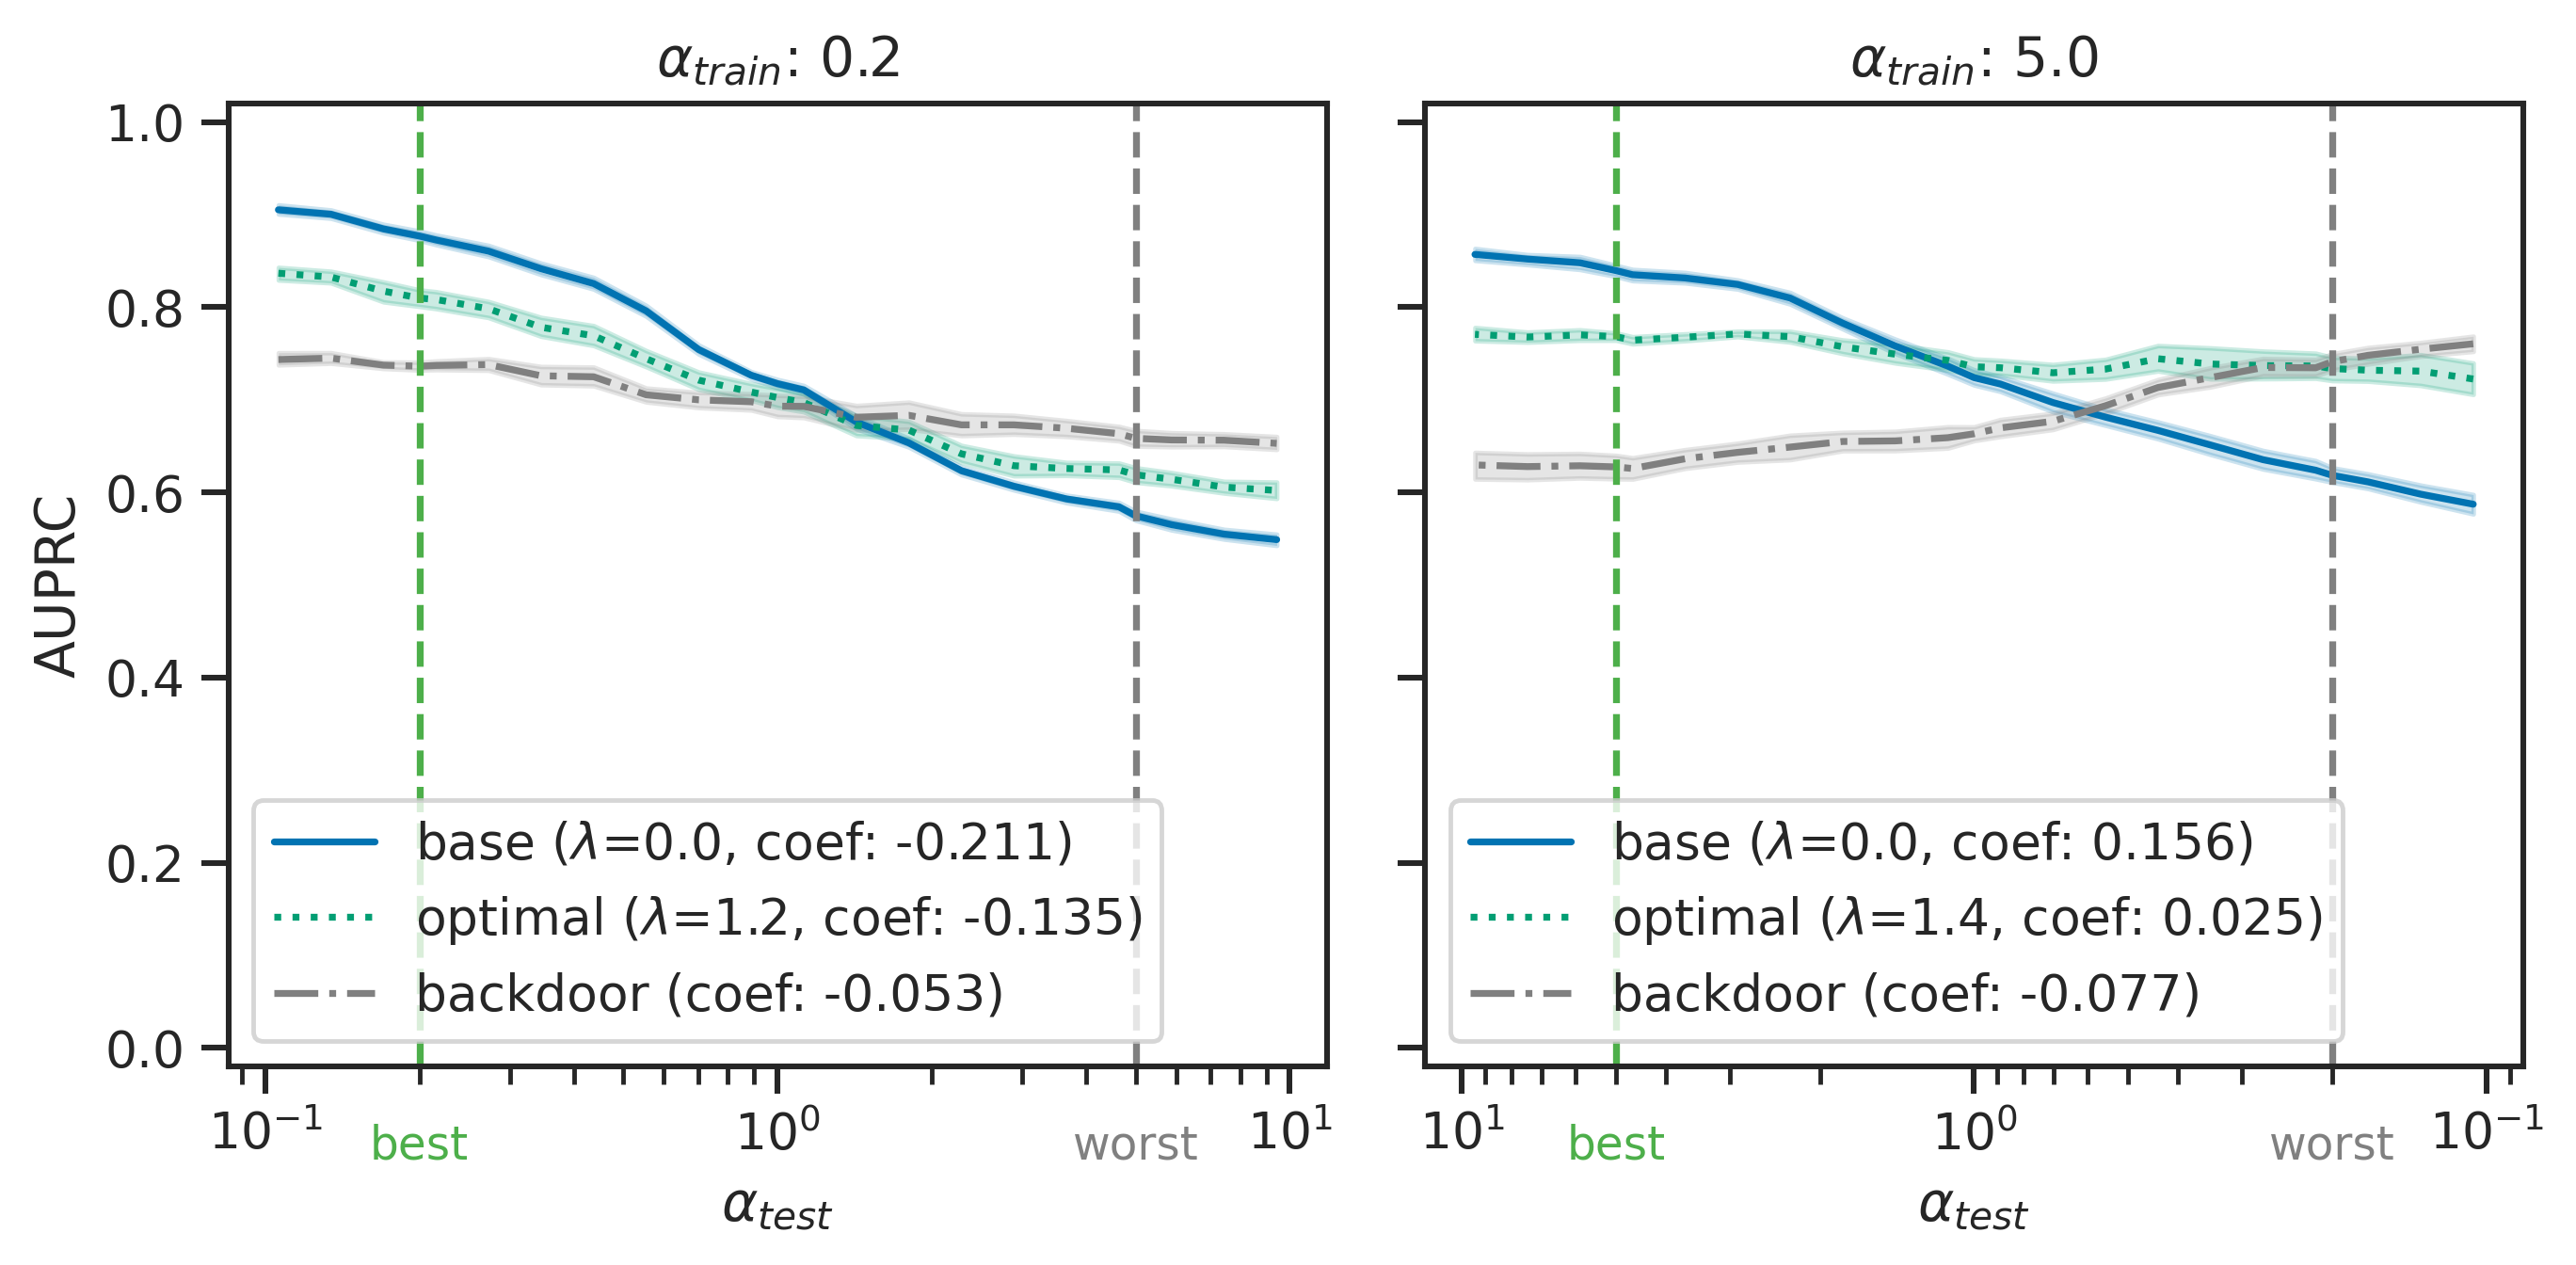

In [23]:
### DAPPER: Dominance-Aware Provenance Source/ReverseSource - Two Plots (0.2 vs 5) - add backdoor

savefig = False
# savefig = True

my_palette = sns.color_palette("colorblind", 3)
my_linestyle = ['solid','dotted', 'dashdot']
xticks = [0.1,1,10]


outname = f"../output/TaskVectorFigs/fig_DA_Optimal_and_Base_TwoPlots_{dataset_name}_{modelUsed}_Cz_0.5_Cy_0.5.png"


_df = deepcopy(df_eval)
_df_backdoor = deepcopy(df_eval_backdoor)

_df_backdoor = _df_backdoor.query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)



# _df['alpha_test'] = _df.apply(lambda x: 1/x['alpha_test'] if x['set'] in [566, 1152] else x['alpha_test'], axis=1)



if dataset_name in ["CD", "HateSpeech"]:
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 566)) | (_df["tv_direction"] == "ReverseSource") & (_df["set"] == 6621)].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)
elif dataset_name == "SHAC":
    _df = _df[((_df["tv_direction"] == "Source") & (_df["set"] == 1152)) | (_df["tv_direction"] == "ReverseSource") & (_df["set"] == 11063)].query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)

xname = "alpha_test"
ylabel = "auprc_weightsEdited"

fig, ax = plt.subplots(1,2,figsize=(8,4), sharey=True)


for i, (set_i, alpha_train) in enumerate(zip(sets_reduce_ls, alpha_train_reduce_ls)):



    df_sub = _df[_df['set'] == set_i]
    df_sub_backdoor = _df_backdoor[_df_backdoor['set'] == set_i]

    for _i, baseOrEdited in enumerate(['base', 'edited']):
        c = my_palette[_i]

        if (baseOrEdited == 'edited'):
            c = my_palette[-1]

        _df_plt = df_sub[df_sub['baseOrEdited'] == baseOrEdited].copy()
        reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))

        lambda_com = _df_plt['lambda2'].unique()
        assert len(lambda_com) == 1
        lambda_com = lambda_com[0]
        
        if baseOrEdited == 'base':
            vlabel = 'base ' + r"($\lambda$=" + f"{lambda_com:.1f}" + f", coef: {reg[0]:.3f})"
        elif baseOrEdited == 'edited':
            vlabel = 'optimal ' + r"($\lambda$=" + f"{lambda_com:.1f}" + f", coef: {reg[0]:.3f})"
            
        sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
                     c=c, 
                     linestyle=my_linestyle[_i], 
                     label=vlabel,
                     # label=r"$\lambda$=" +f"{lambda_com:.1f}" + f" (coef: {reg[0]:.3f})"
                    )
        
#     for ilambda, lambda_com in enumerate([0.0, 1.0]):
#         c = my_palette[ilambda]

#         if (lambda_com == 1.0):
#             c = my_palette[-1]

#         _df_plt = df_sub[df_sub['lambda2'] == lambda_com].copy()
#         reg = get_coefLog10(x=list(_df_plt[xname]), y=list(_df_plt[ylabel]))

#         sns.lineplot(data=_df_plt, x=xname, y=ylabel, ax=ax[i], 
#                      c=c, 
#                      linestyle=my_linestyle[ilambda], label=r"$\lambda$=" +f"{lambda_com:.1f}" + f" (coef: {reg[0]:.3f})"
#                     )


    reg_backdoor = get_coefLog10(x=list(df_sub_backdoor[xname]), y=list(df_sub_backdoor[ylabel]))

    sns.lineplot(data=df_sub_backdoor, x=xname, y=ylabel, ax=ax[i], 
                     c='grey', 
                     linestyle=my_linestyle[2], label=r"backdoor" + f" (coef: {reg_backdoor[0]:.3f})"
                    )
    ax[i].set_xscale('log')

    ax[i].axvline(set_alpha_train_DICT[set_i], color="#4DAF4A", linestyle='dashed')
    ax[i].axvline(1/set_alpha_train_DICT[set_i], color="grey", linestyle='dashed')
    ax[i].text(x=set_alpha_train_DICT[set_i], y=-0.12, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
    ax[i].text(x=1/set_alpha_train_DICT[set_i], y=-0.12, s='worst', color="grey", fontsize=10, horizontalalignment='center')


    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((-0.02,1.02))
    ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")

    if set_i in [566, 1152]:
        ax[i].invert_xaxis()


plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

# Summary Results - Scaling Factor

In [3]:
sns.set_theme(rc={"figure.dpi": 350})
sns.set_context("paper")
# sns.set_theme(style='white')

In [4]:
itertools.product(['CD','HateSpeech'], ['RoBERTa', 'Llama'])

## Show Lambda1 and Lambda2

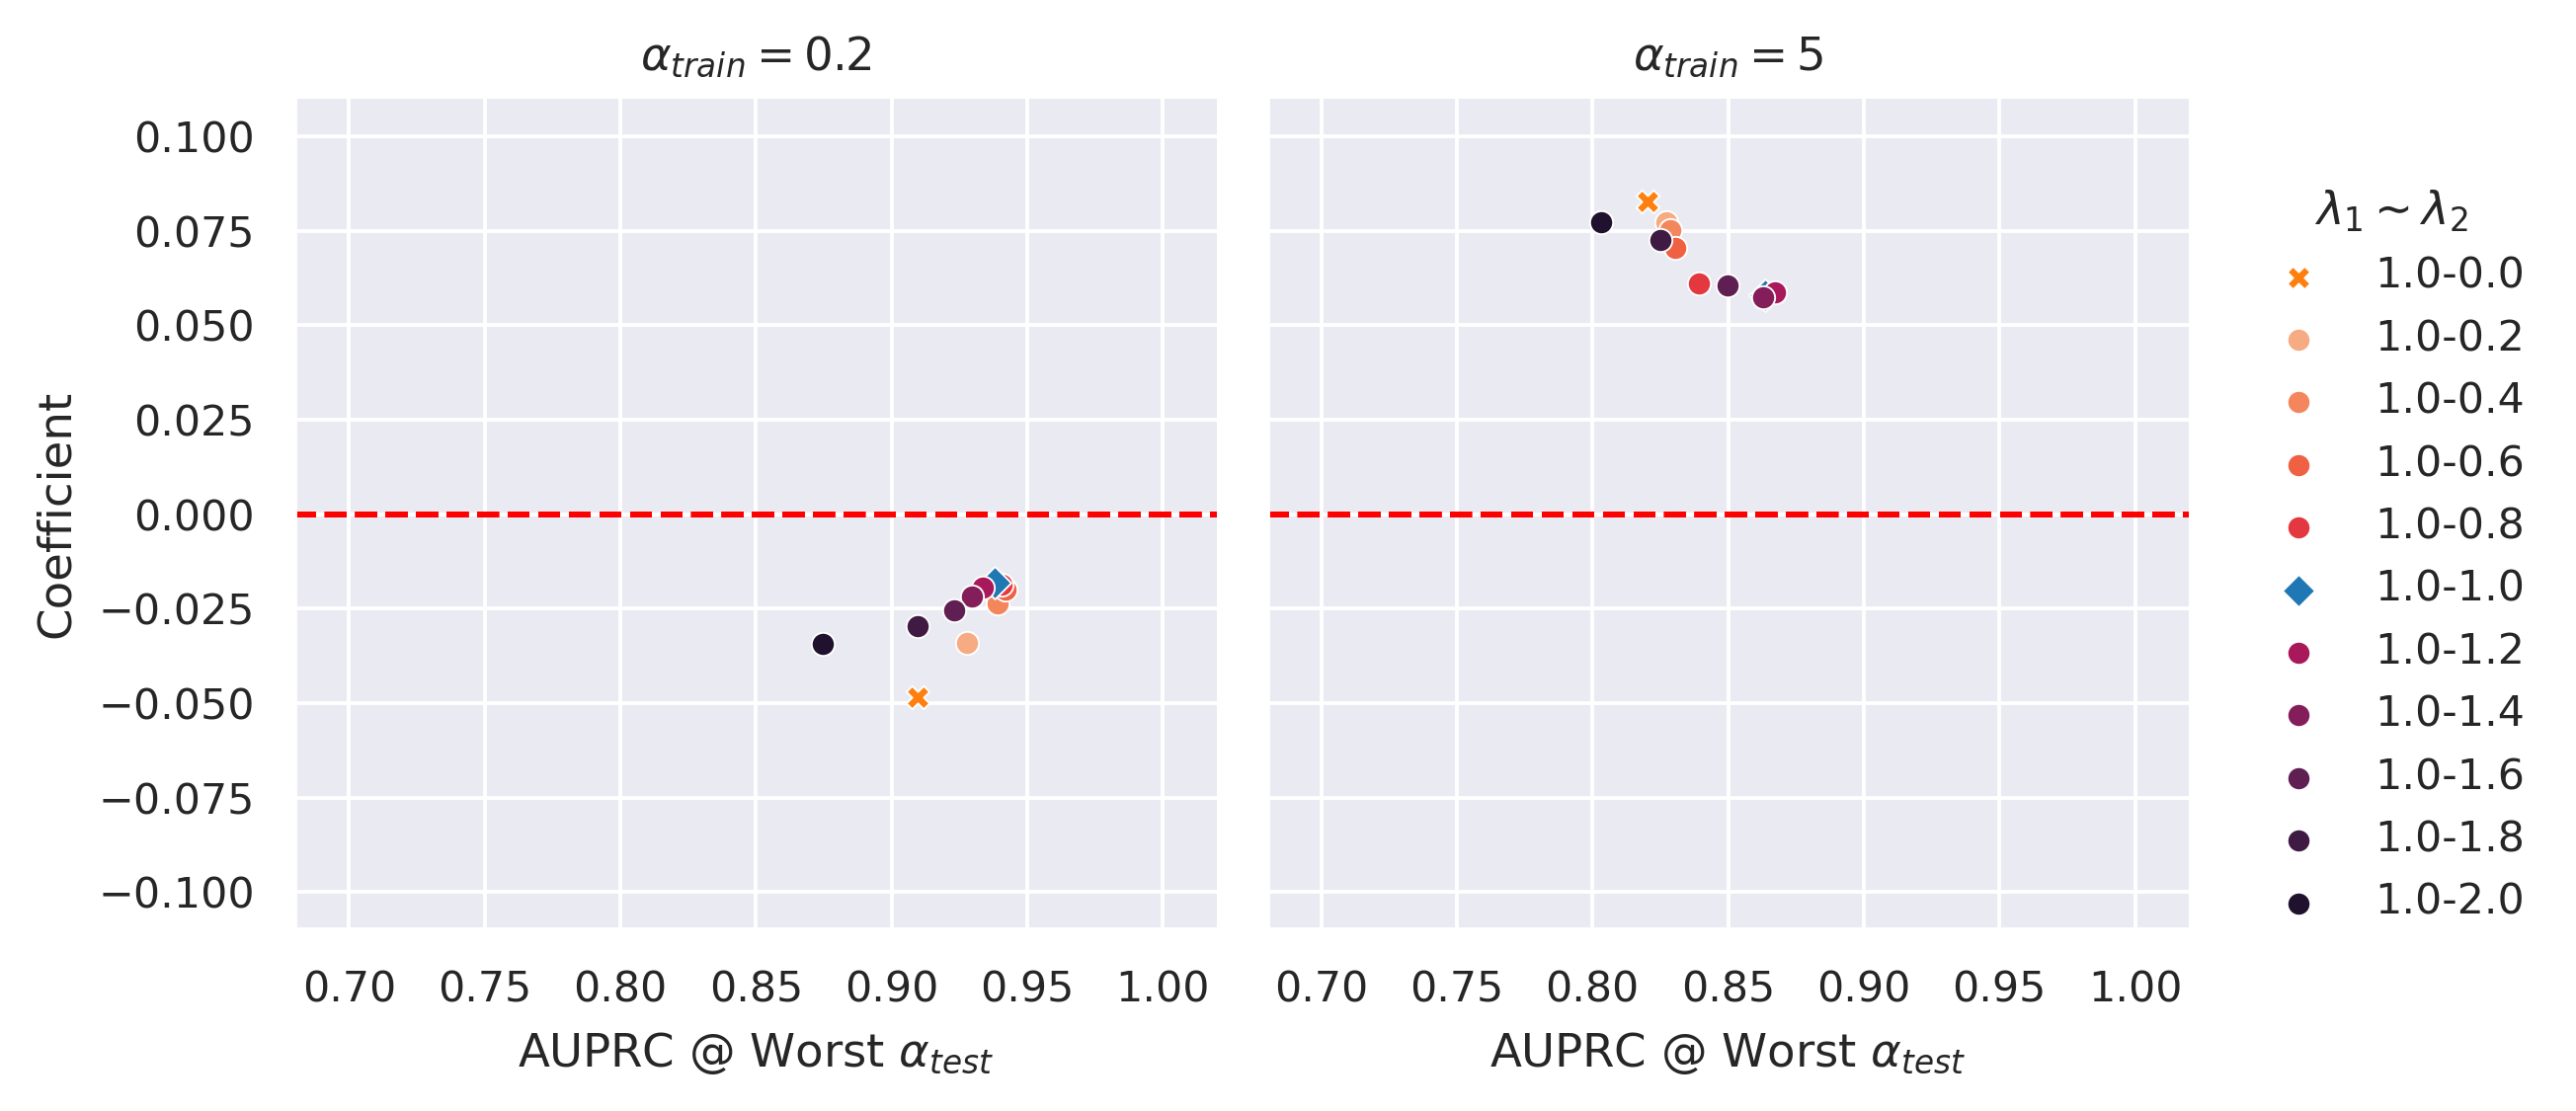

In [4]:
# # dataset_name = "HateSpeech"
# dataset_name = "CD"
# set1 = 566
# set2 = 6621

# set1 = set2 = 3636

# # modelUsed = "Llama"
# modelUsed = "RoBERTa"


savefig = False

# for dataset_name, modelUsed in itertools.product(['HateSpeech'], 
#                                                  # ['CD','HateSpeech'],
#                                                  # ['RoBERTa', 'Llama']
#                                                  ['RoBERTa']
#                                                 ):

#     set1 = 566
#     set2 = 6621
#     # set1 = set2 = 3636

for dataset_name, modelUsed in itertools.product(["SHAC"],
                                                 ['RoBERTa'],
                                                 # ['RoBERTa', 'Llama']
                                                ):
    set1 = 1152
    set2 = 11063
    # set1 = set2 = 6114

    lambda2_ls = ['0.0', '0.2', '0.4', '0.6', '0.8', '1.0', '1.2', '1.4', '1.6', '1.8', '2.0']

    if modelUsed == "Llama":
        ## llama2
        original_template = "../output/tmpData/{}/summary/original/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.csv"
        reverse_template = "../output/tmpData/{}/summary/ReverseSource/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.csv"
    elif modelUsed == "RoBERTa":
        # roberta
        original_template = "../output/roberta/{}/summary/original/Eval-set-{}-epoch3-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.csv"
        reverse_template = "../output/roberta/{}/summary/ReverseSource/Eval-set-{}-epoch3-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.csv"



    #### for 1.0 setting
    files_original = [original_template.format(dataset_name, s, 1.0, l2) for s, l2 in itertools.product([set1], lambda2_ls)]
    files_reverseSource = [reverse_template.format(dataset_name, s, 1.0, l2) for s, l2 in itertools.product([set2], lambda2_ls)]


    df_list = []
    for dirx,sr in zip([files_original, files_reverseSource], ['Source','ReverseSource']):
        for file_i in dirx:
            tmpdf = pd.read_csv(file_i)
            # tmpdf['model'] = dirx.split("/")[-1]
            tmpdf = tmpdf.assign(set = tmpdf['set'].astype(str) + "-" + sr)
            df_list.append(tmpdf)



    df_summary = pd.concat(df_list).reset_index(drop=True)

    lambdaVar = "lambda1_lambda2"

    lambda_levels = ["1.0-0.0", "1.0-0.2", "1.0-0.4", "1.0-0.6", "1.0-0.8", "1.0-1.0", "1.0-1.2", "1.0-1.4", "1.0-1.6", "1.0-1.8", "1.0-2.0", ]

    df_summary[lambdaVar] = df_summary.apply(lambda x: f"{x['lambda1']}-{x['lambda2']}", axis=1)

    df_summary[lambdaVar] = pd.Categorical(df_summary[lambdaVar], categories=lambda_levels)


    #### for 1.0 setting
    my_palette = sns.color_palette("rocket_r", (df_summary[lambdaVar].nunique()))
    plt_extra = sns.color_palette("tab10", 2)[::-1]


    markers = ["o"]*(len(lambda_levels))
    for idx,l in enumerate(lambda_levels):
        if l == "1.0-0.0":
            markers[idx] = "X"
            my_palette[idx] = plt_extra[0]
        elif l == "1.0-1.0":
            markers[idx] = "D"
            my_palette[idx] = plt_extra[1]
    hue_kws={"marker" : markers, 
             # "s":[14]*len(lambda_levels)
            }

    # hue_kws={}

    if modelUsed == "Llama":
        ## llama 2
        if dataset_name == "SHAC":
            ylim = (-0.17,0.17)
            xlim=(0.28,1.02)
        elif dataset_name == "CD":
            # ylim = (-0.35,0.35)
            # xlim = (0.28, 1.02)

            ylim = (-0.34,0.34)
            xlim = (0.38, 1.02)
        elif dataset_name == "HateSpeech":
            ylim = (-0.32,0.32)
            xlim = (0.38,1.02)
    elif modelUsed == "RoBERTa":
        ## roberta
        if dataset_name == "SHAC":
            ylim = (-0.11,0.11)
            xlim=(0.68,1.02)
            if set1 == set2 == 6114:
                ylim = (-0.042,0.042)
                xlim=(0.84,1.02)
        elif dataset_name == "CD":
            ylim = (-0.23,0.23)
            xlim = (0.58, 1.02)
            if set1 == set2 == 3636:
                ylim = (-0.13,0.13)
                xlim=(0.68,1.02)
        elif dataset_name == "HateSpeech":
            ylim = (-0.32,0.32)
            xlim = (0.38,1.02)
            if set1 == set2 == 3636:
                ylim = (-0.11,0.11)
                xlim=(0.58,1.02)





    #####  For Save Only!! 
    ###   Save Plot: Worst alpha
    # savefig = False
    


    outname = f"../output/TaskVectorFigs/fig_ScalingLambdas_WorstAlpha_{dataset_name}_{modelUsed}_Set1_{set1}_Set2_{set2}_Cy_0.5.png"

    _df_plt = deepcopy(df_summary.query("cy.isin([0.5])"))

    if set1 == set2:
        _df_plt['set'] = pd.Categorical(_df_plt['set'], categories=[f'{set1}-ReverseSource', f'{set1}-Source'])
    else:
        if dataset_name in ["CD", "HateSpeech"]:
            _df_plt['set'] = pd.Categorical(_df_plt['set'], categories=['6621-ReverseSource', '566-Source'])
        elif dataset_name in ["SHAC"]:
            _df_plt['set'] = pd.Categorical(_df_plt['set'], categories=['11063-ReverseSource', '1152-Source'])

    # if (dataset_name == "SHAC") and (modelUsed == "Llama"):
    #     break
    g = sns.FacetGrid(data=_df_plt, row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws, height=3.3)
    g.map(sns.scatterplot, "y_alpha_train_recip", "coef")
    g.add_legend()
    g.set(xlabel=r"AUPRC @ Worst $\alpha_{test}$")
    # g.set(ylim=(-0.25,0.25))
    # # g.set(ylim=(-0.04,0.04))
    # g.set(ylim=(-0.3,0.15))
    # g.set(ylim=(-0.17,0.17))
    # g.set(ylim=(-0.33,0.33))

    g.set(ylim=ylim)
    g.set(xlim=xlim)

    # g.set(xlim=(0.90,1))

    g.hue_kws = {}
    g.map(plt.axhline, y=0, ls='--', c='red')

    axes = g.axes.flatten()
    for ax in axes:
        g.legend.set_title(r"$\lambda_1 \sim \lambda_2$")
        if  ("6621-ReverseSource" in ax.title.get_text()) or ("11063-ReverseSource" in ax.title.get_text()):
            ax.set_title(r"$\alpha_{train}=0.2$")
        elif ("566-Source" in ax.title.get_text()) or ("1152-Source" in ax.title.get_text()):
            ax.set_title(r"$\alpha_{train}=5$")
        elif ("3636" in ax.title.get_text()) or ("6114" in ax.title.get_text()):
            if "-Source" in ax.title.get_text():
                ax.set_title(r"$\alpha_{train}=1$ [$P(Z=z_2)$]")
            elif "-ReverseSource" in ax.title.get_text():
                ax.set_title(r"$\alpha_{train}=1$ [$P(Z=z_1)$]")

    g.set_ylabels("Coefficient")
    sns.move_legend(g, 'center right', bbox_to_anchor=(0.94, 0.5)
                   )

    # plt.tight_layout()

    if savefig:
        plt.savefig(outname, dpi=600, bbox_inches='tight')
    else:
        plt.show()

    plt.close()

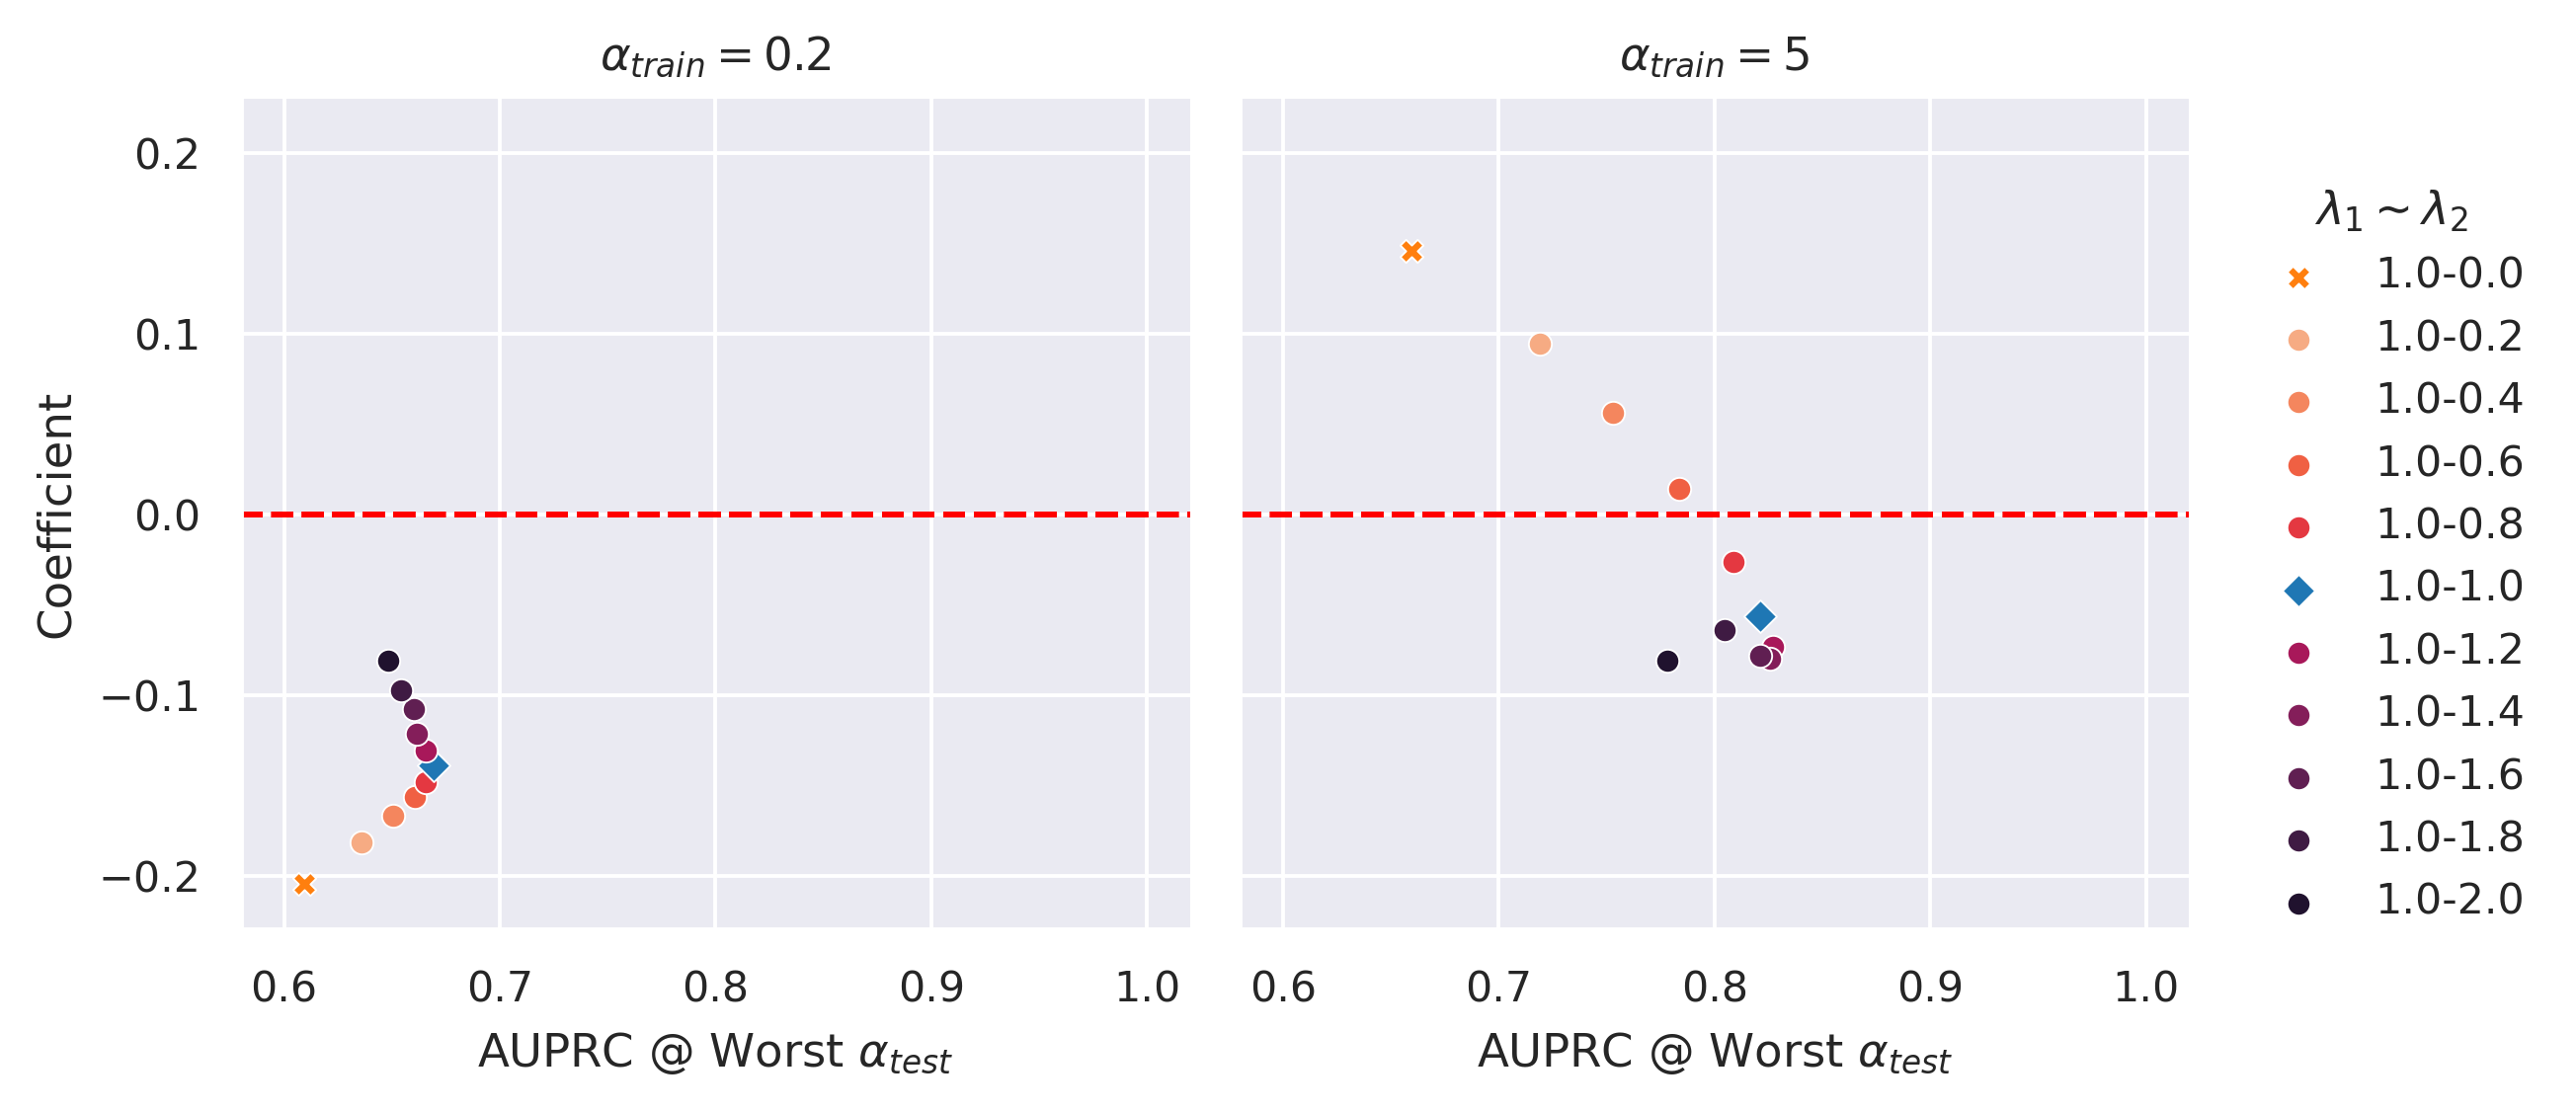

In [24]:
# # dataset_name = "HateSpeech"
# dataset_name = "CD"
# set1 = 566
# set2 = 6621

# set1 = set2 = 3636

# # modelUsed = "Llama"
# modelUsed = "RoBERTa"


savefig = False

# for dataset_name, modelUsed in itertools.product(['HateSpeech'], ['Llama']):
for dataset_name, modelUsed in itertools.product(['CD'], ['RoBERTa']):

    set1 = 566
    set2 = 6621
    # set1 = set2 = 3636


    lambda2_ls = ['0.0', '0.2', '0.4', '0.6', '0.8', '1.0', '1.2', '1.4', '1.6', '1.8', '2.0']

    if modelUsed == "Llama":
        ## llama2
        original_template = "../output/tmpData/{}/summary/original/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.csv"
        reverse_template = "../output/tmpData/{}/summary/ReverseSource/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.csv"
    elif modelUsed == "RoBERTa":
        # roberta
        original_template = "../output/roberta/{}/summary/original/Eval-set-{}-epoch3-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.csv"
        reverse_template = "../output/roberta/{}/summary/ReverseSource/Eval-set-{}-epoch3-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.csv"



    #### for 1.0 setting
    files_original = [original_template.format(dataset_name, s, 1.0, l2) for s, l2 in itertools.product([set1], lambda2_ls)]
    files_reverseSource = [reverse_template.format(dataset_name, s, 1.0, l2) for s, l2 in itertools.product([set2], lambda2_ls)]


    df_list = []
    for dirx,sr in zip([files_original, files_reverseSource], ['Source','ReverseSource']):
        for file_i in dirx:
            tmpdf = pd.read_csv(file_i)
            # tmpdf['model'] = dirx.split("/")[-1]
            tmpdf = tmpdf.assign(set = tmpdf['set'].astype(str) + "-" + sr)
            df_list.append(tmpdf)


    df_summary = pd.concat(df_list).reset_index(drop=True)

    lambdaVar = "lambda1_lambda2"
    lambda_levels = ["1.0-0.0", "1.0-0.2", "1.0-0.4", "1.0-0.6", "1.0-0.8", "1.0-1.0", "1.0-1.2", "1.0-1.4", "1.0-1.6", "1.0-1.8", "1.0-2.0", ]
    df_summary[lambdaVar] = df_summary.apply(lambda x: f"{x['lambda1']}-{x['lambda2']}", axis=1)

    
#     lambdaVar = "lambda2"
#     df_summary[lambdaVar] = df_summary[lambdaVar].astype(str)

#     lambda_levels = ["0.0", "0.2", "0.4", "0.6", "0.8", "1.0", "1.2", "1.4", "1.6", "1.8", "2.0", ]

    df_summary[lambdaVar] = pd.Categorical(df_summary[lambdaVar], categories=lambda_levels)


    #### for 1.0 setting
    my_palette = sns.color_palette("rocket_r", (df_summary[lambdaVar].nunique()))
    plt_extra = sns.color_palette("tab10", 2)[::-1]


    markers = ["o"]*(len(lambda_levels))
    for idx,l in enumerate(lambda_levels):
        if l == "1.0-0.0":
        # if l == "0.0":
            markers[idx] = "X"
            my_palette[idx] = plt_extra[0]
        elif l == "1.0-1.0":
        # elif l == "1.0":
            markers[idx] = "D"
            my_palette[idx] = plt_extra[1]
    hue_kws={"marker" : markers, 
             # "s":[14]*len(lambda_levels)
            }

    # hue_kws={}

    if modelUsed == "Llama":
        ## llama 2
        if dataset_name == "SHAC":
            ylim = (-0.17,0.17)
            xlim=(0.28,1.02)
        elif dataset_name == "CD":
            # ylim = (-0.35,0.35)
            # xlim = (0.28, 1.02)

            ylim = (-0.34,0.34)
            xlim = (0.38, 1.02)
        elif dataset_name == "HateSpeech":
            ylim = (-0.32,0.32)
            xlim = (0.38,1.02)
    elif modelUsed == "RoBERTa":
        ## roberta
        if dataset_name == "SHAC":
            ylim = (-0.11,0.11)
            xlim=(0.68,1.02)
            if set1 == set2 == 6114:
                ylim = (-0.042,0.042)
                xlim=(0.84,1.02)
        elif dataset_name == "CD":
            ylim = (-0.23,0.23)
            xlim = (0.58, 1.02)
            if set1 == set2 == 3636:
                ylim = (-0.13,0.13)
                xlim=(0.68,1.02)
        elif dataset_name == "HateSpeech":
            ylim = (-0.32,0.32)
            xlim = (0.38,1.02)
            if set1 == set2 == 3636:
                ylim = (-0.11,0.11)
                xlim=(0.58,1.02)





    #####  For Save Only!! 
    ###   Save Plot: Worst alpha
    # savefig = False
    


    outname = f"../output/TaskVectorFigs/fig_ScalingLambdas_WorstAlpha_{dataset_name}_{modelUsed}_Set1_{set1}_Set2_{set2}_Cy_0.5.png"

    _df_plt = deepcopy(df_summary.query("cy.isin([0.5])"))

    if set1 == set2:
        _df_plt['set'] = pd.Categorical(_df_plt['set'], categories=[f'{set1}-ReverseSource', f'{set1}-Source'])
    else:
        if dataset_name in ["CD", "HateSpeech"]:
            _df_plt['set'] = pd.Categorical(_df_plt['set'], categories=['6621-ReverseSource', '566-Source'])
        elif dataset_name in ["SHAC"]:
            _df_plt['set'] = pd.Categorical(_df_plt['set'], categories=['11063-ReverseSource', '1152-Source'])


    g = sns.FacetGrid(data=_df_plt, row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws, height=3.3)
    g.map(sns.scatterplot, "y_alpha_train_recip", "coef")
    g.add_legend()
    g.set(xlabel=r"AUPRC @ Worst $\alpha_{test}$")
    # g.set(ylim=(-0.25,0.25))
    # # g.set(ylim=(-0.04,0.04))
    # g.set(ylim=(-0.3,0.15))
    # g.set(ylim=(-0.17,0.17))
    # g.set(ylim=(-0.33,0.33))

    g.set(ylim=ylim)
    g.set(xlim=xlim)

    # g.set(xlim=(0.90,1))

    g.hue_kws = {}
    g.map(plt.axhline, y=0, ls='--', c='red')

    axes = g.axes.flatten()
    for ax in axes:
        g.legend.set_title(r"$\lambda_1 \sim \lambda_2$")
        # g.legend.set_title(r"$\lambda$")

        
        
        if  ("6621-ReverseSource" in ax.title.get_text()) or ("11063-ReverseSource" in ax.title.get_text()):
            ax.set_title(r"$\alpha_{train}=0.2$")
        elif ("566-Source" in ax.title.get_text()) or ("1152-Source" in ax.title.get_text()):
            ax.set_title(r"$\alpha_{train}=5$")
        elif ("3636" in ax.title.get_text()) or ("6114" in ax.title.get_text()):
            if "-Source" in ax.title.get_text():
                ax.set_title(r"$\alpha_{train}=1$ [$P(Z=z_2)$]")
            elif "-ReverseSource" in ax.title.get_text():
                ax.set_title(r"$\alpha_{train}=1$ [$P(Z=z_1)$]")

    g.set_ylabels("Coefficient")
    sns.move_legend(g, 'center right', bbox_to_anchor=(0.94, 0.5)
                   )

    # plt.tight_layout()

    if savefig:
        plt.savefig(outname, dpi=600, bbox_inches='tight')
    else:
        plt.show()

    plt.close()

## Only Show lambda2

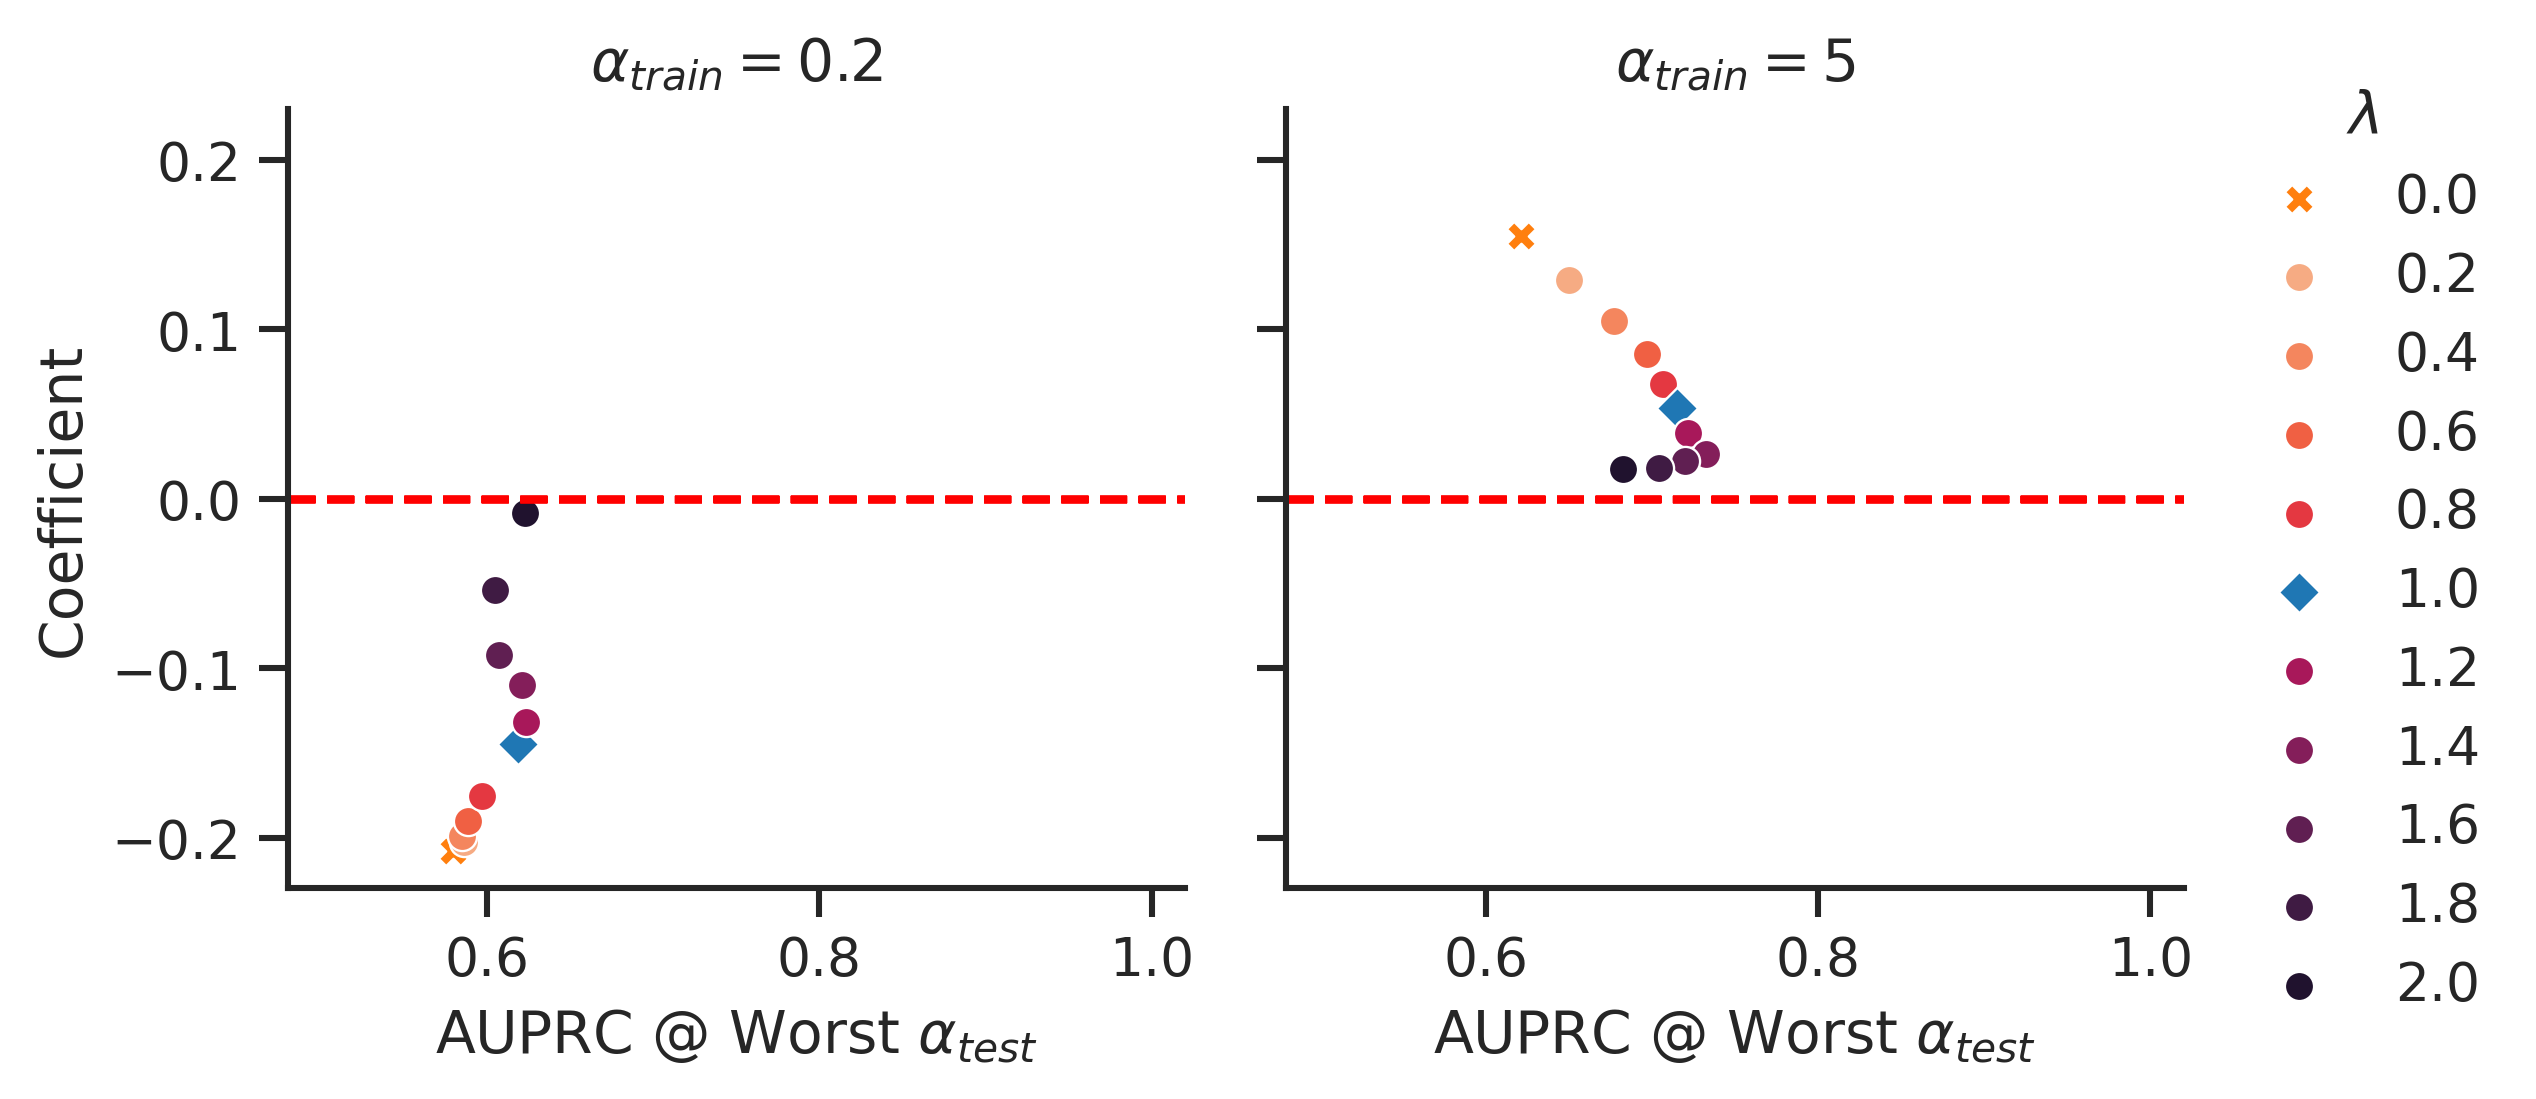

In [55]:
## CD & HateSpeech


savefig = False
# savefig = True

# for dataset_name, modelUsed in itertools.product(['CD', 'HateSpeech'], ['RoBERTa']):
for dataset_name, modelUsed in itertools.product(['CD'], ['RoBERTa']):

    set1 = 566
    set2 = 6621
    # set1 = set2 = 3636

# for dataset_name, modelUsed in itertools.product(["SHAC"],
#                                                  ['Llama']
#                                                  # ['RoBERTa', 'Llama']
#                                                 ):
#     set1 = 1152
#     set2 = 11063
#     # set1 = set2 = 6114

    lambda2_ls = ['0.0', '0.2', '0.4', '0.6', '0.8', '1.0', '1.2', '1.4', '1.6', '1.8', '2.0']

    if modelUsed == "Llama":
        ## llama2
        original_template = "../output/tmpData/{}/summary/original/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.csv"
        reverse_template = "../output/tmpData/{}/summary/ReverseSource/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.csv"
    elif modelUsed == "RoBERTa":
        # roberta
        original_template = "../output/roberta/{}/summary/original/Eval-set-{}-epoch3-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.csv"
        reverse_template = "../output/roberta/{}/summary/ReverseSource/Eval-set-{}-epoch3-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5.csv"



    #### for 1.0 setting
    files_original = [original_template.format(dataset_name, s, 1.0, l2) for s, l2 in itertools.product([set1], lambda2_ls)]
    files_reverseSource = [reverse_template.format(dataset_name, s, 1.0, l2) for s, l2 in itertools.product([set2], lambda2_ls)]


    df_list = []
    for dirx,sr in zip([files_original, files_reverseSource], ['Source','ReverseSource']):
        for file_i in dirx:
            tmpdf = pd.read_csv(file_i)
            # tmpdf['model'] = dirx.split("/")[-1]
            tmpdf = tmpdf.assign(set = tmpdf['set'].astype(str) + "-" + sr)
            df_list.append(tmpdf)


    df_summary = pd.concat(df_list).reset_index(drop=True)

    # lambdaVar = "lambda1_lambda2"
    # lambda_levels = ["1.0-0.0", "1.0-0.2", "1.0-0.4", "1.0-0.6", "1.0-0.8", "1.0-1.0", "1.0-1.2", "1.0-1.4", "1.0-1.6", "1.0-1.8", "1.0-2.0", ]
    # df_summary[lambdaVar] = df_summary.apply(lambda x: f"{x['lambda1']}-{x['lambda2']}", axis=1)

    
    lambdaVar = "lambda2"
    df_summary[lambdaVar] = df_summary[lambdaVar].astype(str)

    lambda_levels = lambda2_ls

    df_summary[lambdaVar] = pd.Categorical(df_summary[lambdaVar], categories=lambda_levels)


    #### for 1.0 setting
    my_palette = sns.color_palette("rocket_r", (df_summary[lambdaVar].nunique()))
    plt_extra = sns.color_palette("tab10", 2)[::-1]


    markers = ["o"]*(len(lambda_levels))
    for idx,l in enumerate(lambda_levels):
        # if l == "1.0-0.0":
        if l == "0.0":
            markers[idx] = "X"
            my_palette[idx] = plt_extra[0]
        # elif l == "1.0-1.0":
        elif l == "1.0":
            markers[idx] = "D"
            my_palette[idx] = plt_extra[1]
    hue_kws={"marker" : markers, 
             # "s":[14]*len(lambda_levels)
            }

    # hue_kws={}

    if modelUsed == "Llama":
        ## llama 2
        if dataset_name == "SHAC":
            ylim = (-0.17,0.17)
            xlim=(0.28,1.02)
        elif dataset_name == "CD":
            # ylim = (-0.35,0.35)
            # xlim = (0.28, 1.02)

            ylim = (-0.34,0.34)
            xlim = (0.38, 1.02)
        elif dataset_name == "HateSpeech":
            ylim = (-0.32,0.32)
            xlim = (0.38,1.02)
    elif modelUsed == "RoBERTa":
        ## roberta
        if dataset_name == "SHAC":
            ylim = (-0.11,0.11)
            xlim=(0.68,1.02)
            if set1 == set2 == 6114:
                ylim = (-0.042,0.042)
                xlim=(0.84,1.02)
        elif dataset_name == "CD":
            ylim = (-0.23,0.23)
            xlim = (0.48, 1.02)
            if set1 == set2 == 3636:
                ylim = (-0.13,0.13)
                xlim=(0.38,1.02)
        elif dataset_name == "HateSpeech":
            ylim = (-0.32,0.32)
            xlim = (0.38,1.02)
            if set1 == set2 == 3636:
                ylim = (-0.11,0.11)
                xlim=(0.58,1.02)





    #####  For Save Only!! 
    ###   Save Plot: Worst alpha
    # savefig = False
    


    outname = f"../output/TaskVectorFigs/fig_ScalingLambdas_WorstAlpha_{dataset_name}_{modelUsed}_Set1_{set1}_Set2_{set2}_Cy_0.5.png"

    _df_plt = deepcopy(df_summary.query("cy.isin([0.5])"))

    if set1 == set2:
        _df_plt['set'] = pd.Categorical(_df_plt['set'], categories=[f'{set1}-ReverseSource', f'{set1}-Source'])
    else:
        if dataset_name in ["CD", "HateSpeech"]:
            _df_plt['set'] = pd.Categorical(_df_plt['set'], categories=['6621-ReverseSource', '566-Source'])
        elif dataset_name in ["SHAC"]:
            _df_plt['set'] = pd.Categorical(_df_plt['set'], categories=['11063-ReverseSource', '1152-Source'])


    g = sns.FacetGrid(data=_df_plt, row='cy', col='set', hue=lambdaVar, palette=my_palette, hue_kws=hue_kws, height=3.3)
    g.map(sns.scatterplot, "y_alpha_train_recip", "coef")
    g.add_legend()
    g.set(xlabel=r"AUPRC @ Worst $\alpha_{test}$")
    # g.set(ylim=(-0.25,0.25))
    # # g.set(ylim=(-0.04,0.04))
    # g.set(ylim=(-0.3,0.15))
    # g.set(ylim=(-0.17,0.17))
    # g.set(ylim=(-0.33,0.33))

    g.set(ylim=ylim)
    g.set(xlim=xlim)
    
    
    # g.set(xlim=(0.90,1))

    g.hue_kws = {}
    g.map(plt.axhline, y=0, ls='--', c='red')

    axes = g.axes.flatten()
    for ax in axes:
        # g.legend.set_title(r"$\lambda_1 \sim \lambda_2$")
        g.legend.set_title(r"$\lambda$")

        
        
        if  ("6621-ReverseSource" in ax.title.get_text()) or ("11063-ReverseSource" in ax.title.get_text()):
            ax.set_title(r"$\alpha_{train}=0.2$")
        elif ("566-Source" in ax.title.get_text()) or ("1152-Source" in ax.title.get_text()):
            ax.set_title(r"$\alpha_{train}=5$")
        elif ("3636" in ax.title.get_text()) or ("6114" in ax.title.get_text()):
            if "-Source" in ax.title.get_text():
                ax.set_title(r"$\alpha_{train}=1$ [$P(Z=z_2)$]")
            elif "-ReverseSource" in ax.title.get_text():
                ax.set_title(r"$\alpha_{train}=1$ [$P(Z=z_1)$]")

    g.set_ylabels("Coefficient")
    sns.move_legend(g, 'center right', bbox_to_anchor=(0.98, 0.5)
                   )

    # plt.tight_layout()

    if savefig:
        plt.savefig(outname, dpi=600, bbox_inches='tight')
    else:
        plt.show()

    plt.close()

In [56]:
_df_plt[['y_alpha_train_recip', 'lambda2', 'set']]

,y_alpha_train_recip,lambda2,set
4,0.621061,0.0,566-Source
13,0.649927,0.2,566-Source
22,0.677218,0.4,566-Source
31,0.696861,0.6,566-Source
40,0.706538,0.8,566-Source
49,0.715054,1.0,566-Source
58,0.721934,1.2,566-Source
67,0.732379,1.4,566-Source
76,0.720093,1.6,566-Source
85,0.704484,1.8,566-Source


# Task Vector: Check by z0/z1

In [224]:

dataset_name = 'CD'
# set_ls = [566]
# set_i = [566]
# set_i = 566
# source = "Source"

set_i = 6621
source = "ReverseSource"

modelUsed = "RoBERTa"
# modelUsed = "Llama"




if modelUsed == "Llama":
    if source == "Source":
        original_template = "../output/tmpData/{}/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5"
    elif source == "ReverseSource":
        original_template = "../output/tmpData/{}_ReverseSource/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5"
elif modelUsed == "RoBERTa":
    if source == "Source":
        original_template = "../output/roberta/{}/Eval-set-{}-epoch3-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5"
    elif source == "ReverseSource":
        original_template = "../output/roberta/{}_ReverseSource/Eval-set-{}-epoch3-lambda1_{}-lambda2_{}-added-ntest_200-Runs_5"


In [225]:
if dataset_name == "CD":
    z_Categories = ["avh","r56"] 

In [226]:

lambda2_ls = ['0.0', '0.2', '0.4', '0.6', '0.8', '1.0', '1.2', '1.4', '1.6', '1.8', '2.0']



fnames = [original_template.format(dataset_name, s, 1.0, l2) for s, l2 in itertools.product([set_i], lambda2_ls)]


In [227]:
df_eval_ls = []
for fname in fnames:
    with open(f"{fname}.pkl", "rb") as f:
        tmp = pickle.load(file=f)
    name_base = Path(fname).name
    tmp["name"] = name_base
    
    tmp["set"] = name_base.split("-")[2]
    tmp["lambda1"] = float(
        [x for x in name_base.split("-") if x.startswith("lambda1")][0].split("_")[1]
    )
    if 'lambda2' in fname:
        tmp["lambda2"] = float(
            [x for x in name_base.split("-") if x.startswith("lambda2")][0].split("_")[1]
        )
        
    tmp['n_z0_test'] = (tmp['n_z0_pos_test'] + tmp['n_z0_neg_test'])
    tmp['n_z1_test'] = (tmp['n_z1_pos_test'] + tmp['n_z1_neg_test'])

    tmp['freq_z0_test'] = tmp['n_z0_pos_test']/(tmp['n_z0_pos_test'] + tmp['n_z0_neg_test'])
    tmp['freq_z1_test'] = tmp['n_z1_pos_test']/(tmp['n_z1_pos_test'] + tmp['n_z1_neg_test'])


        
    df_eval_ls.append(tmp)
    

In [228]:
df_eval = pd.concat(df_eval_ls)

In [156]:
lambdaVar = "lambda1_lambda2"
# lambda_levels = ["1.5-0.0", "1.5-0.25", "1.5-0.5", "1.5-0.75", "1.5-1.0", "1.5-1.25", "1.5-1.5", "1.5-1.75", "1.5-2.0", "1.5-2.5", "1.5-3.0"]

# lambda_levels = ["1.0-0.0", "1.0-1.0", "1.5-0.0", "1.5-0.25", "1.5-0.5", "1.5-0.75", "1.5-1.0", "1.5-1.25", "1.5-1.5", "1.5-1.75", "1.5-2.0", "1.5-2.5", "1.5-3.0"]

lambda_levels = ["1.0-0.0", "1.0-0.2", "1.0-0.4", "1.0-0.6", "1.0-0.8", "1.0-1.0", "1.0-1.2", "1.0-1.4", "1.0-1.6", "1.0-1.8", "1.0-2.0", ]

df_eval[lambdaVar] = df_eval.apply(lambda x: f"{x['lambda1']}-{x['lambda2']}", axis=1)

df_eval[lambdaVar] = pd.Categorical(df_eval[lambdaVar], categories=lambda_levels)

In [157]:
df_eval.groupby('set').size()

set
6621    333135
dtype: int64

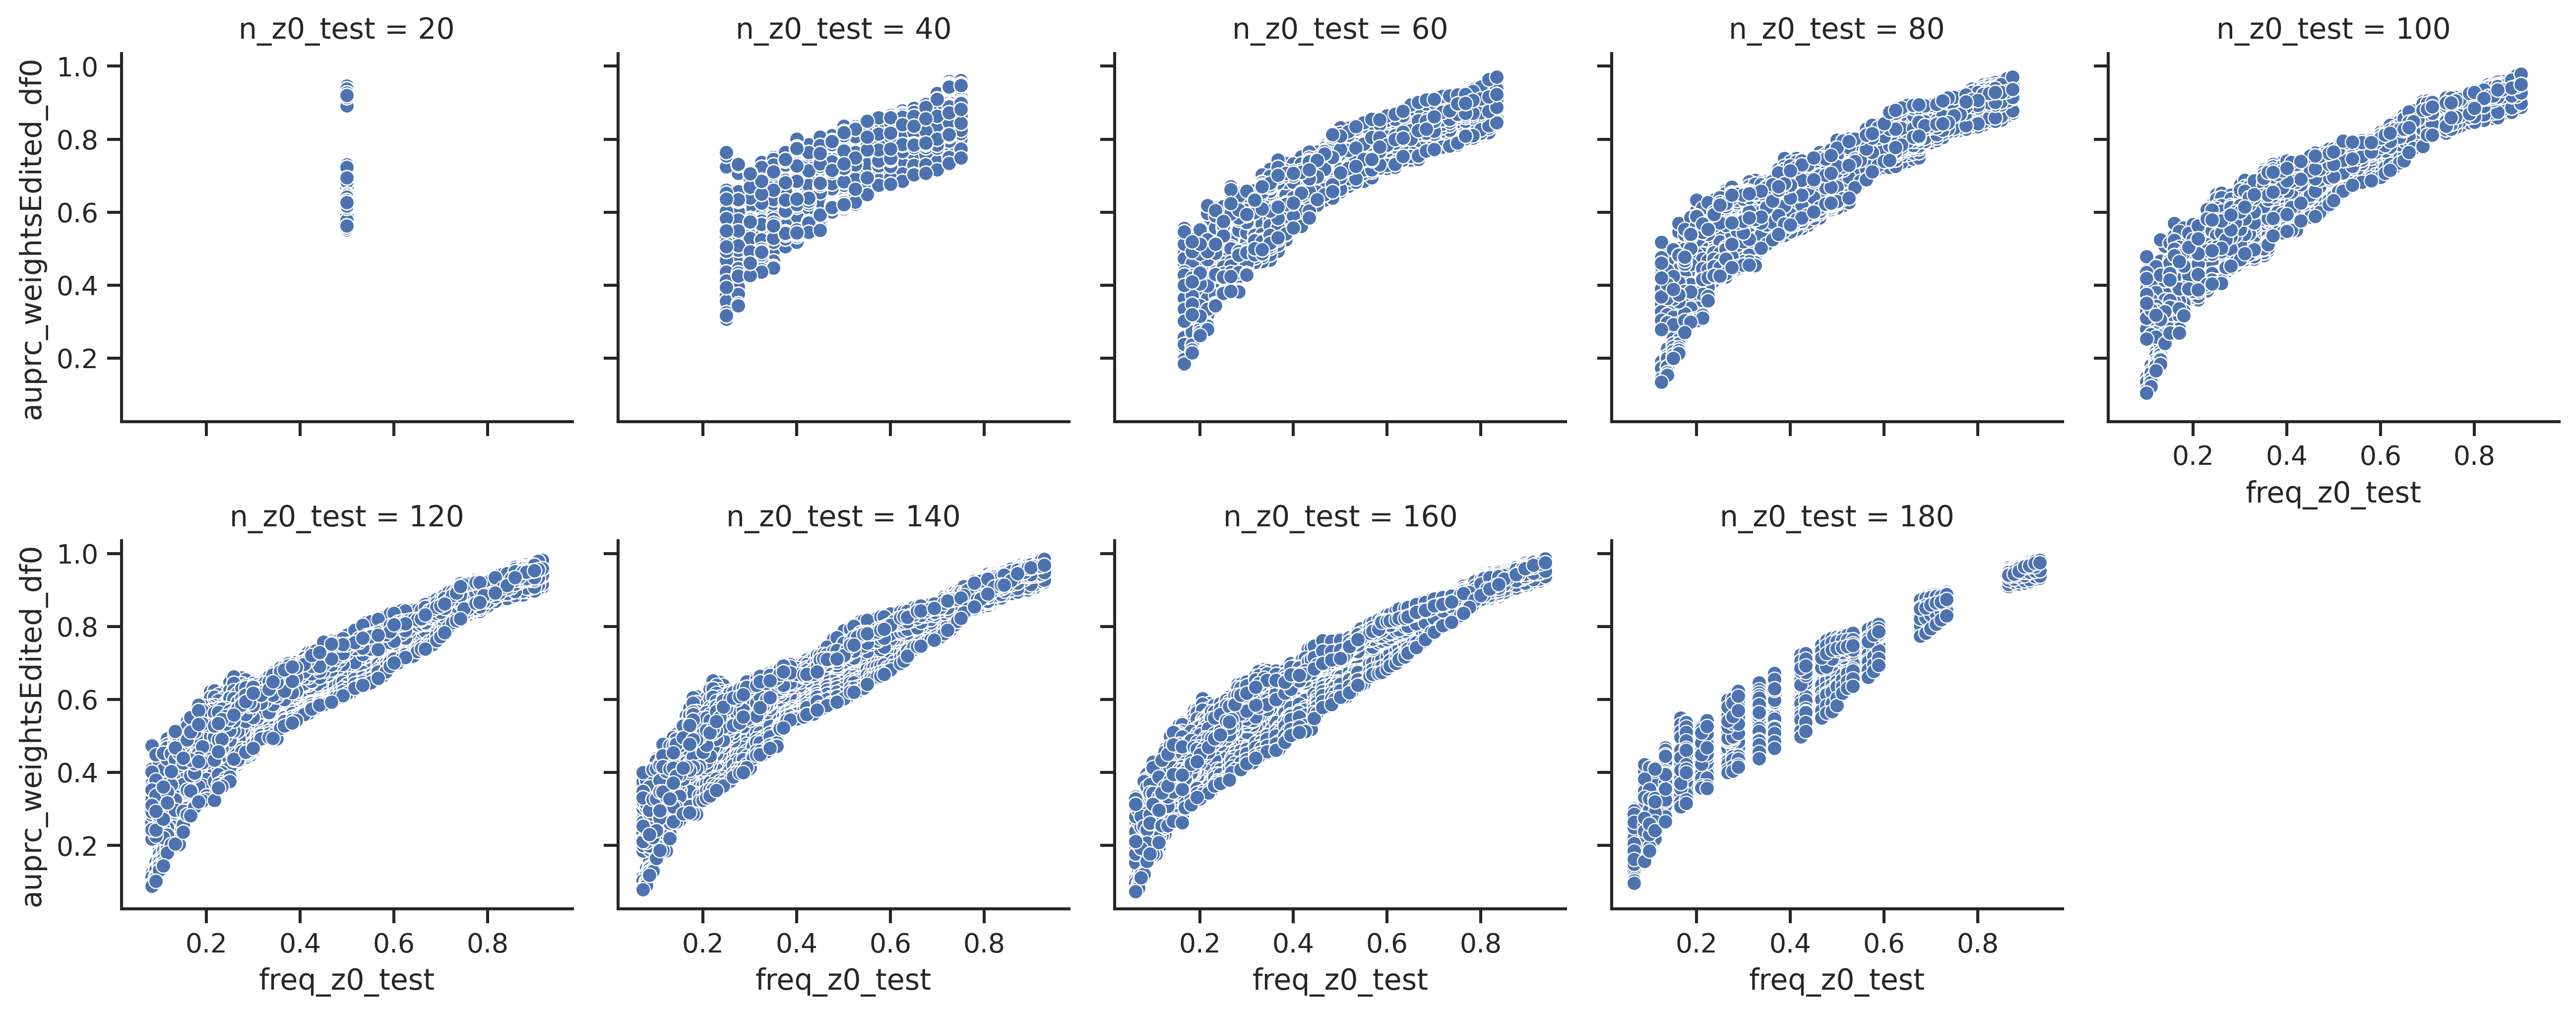

In [104]:
df_plt = deepcopy(df_eval.reset_index(drop=True))

df_plt["C_y"] = df_plt["C_y"].round(2)


g = sns.FacetGrid(data=df_plt, col="n_z0_test", col_wrap=5)

g.map(sns.scatterplot, "freq_z0_test", "auprc_weightsEdited_df0")
plt.show()

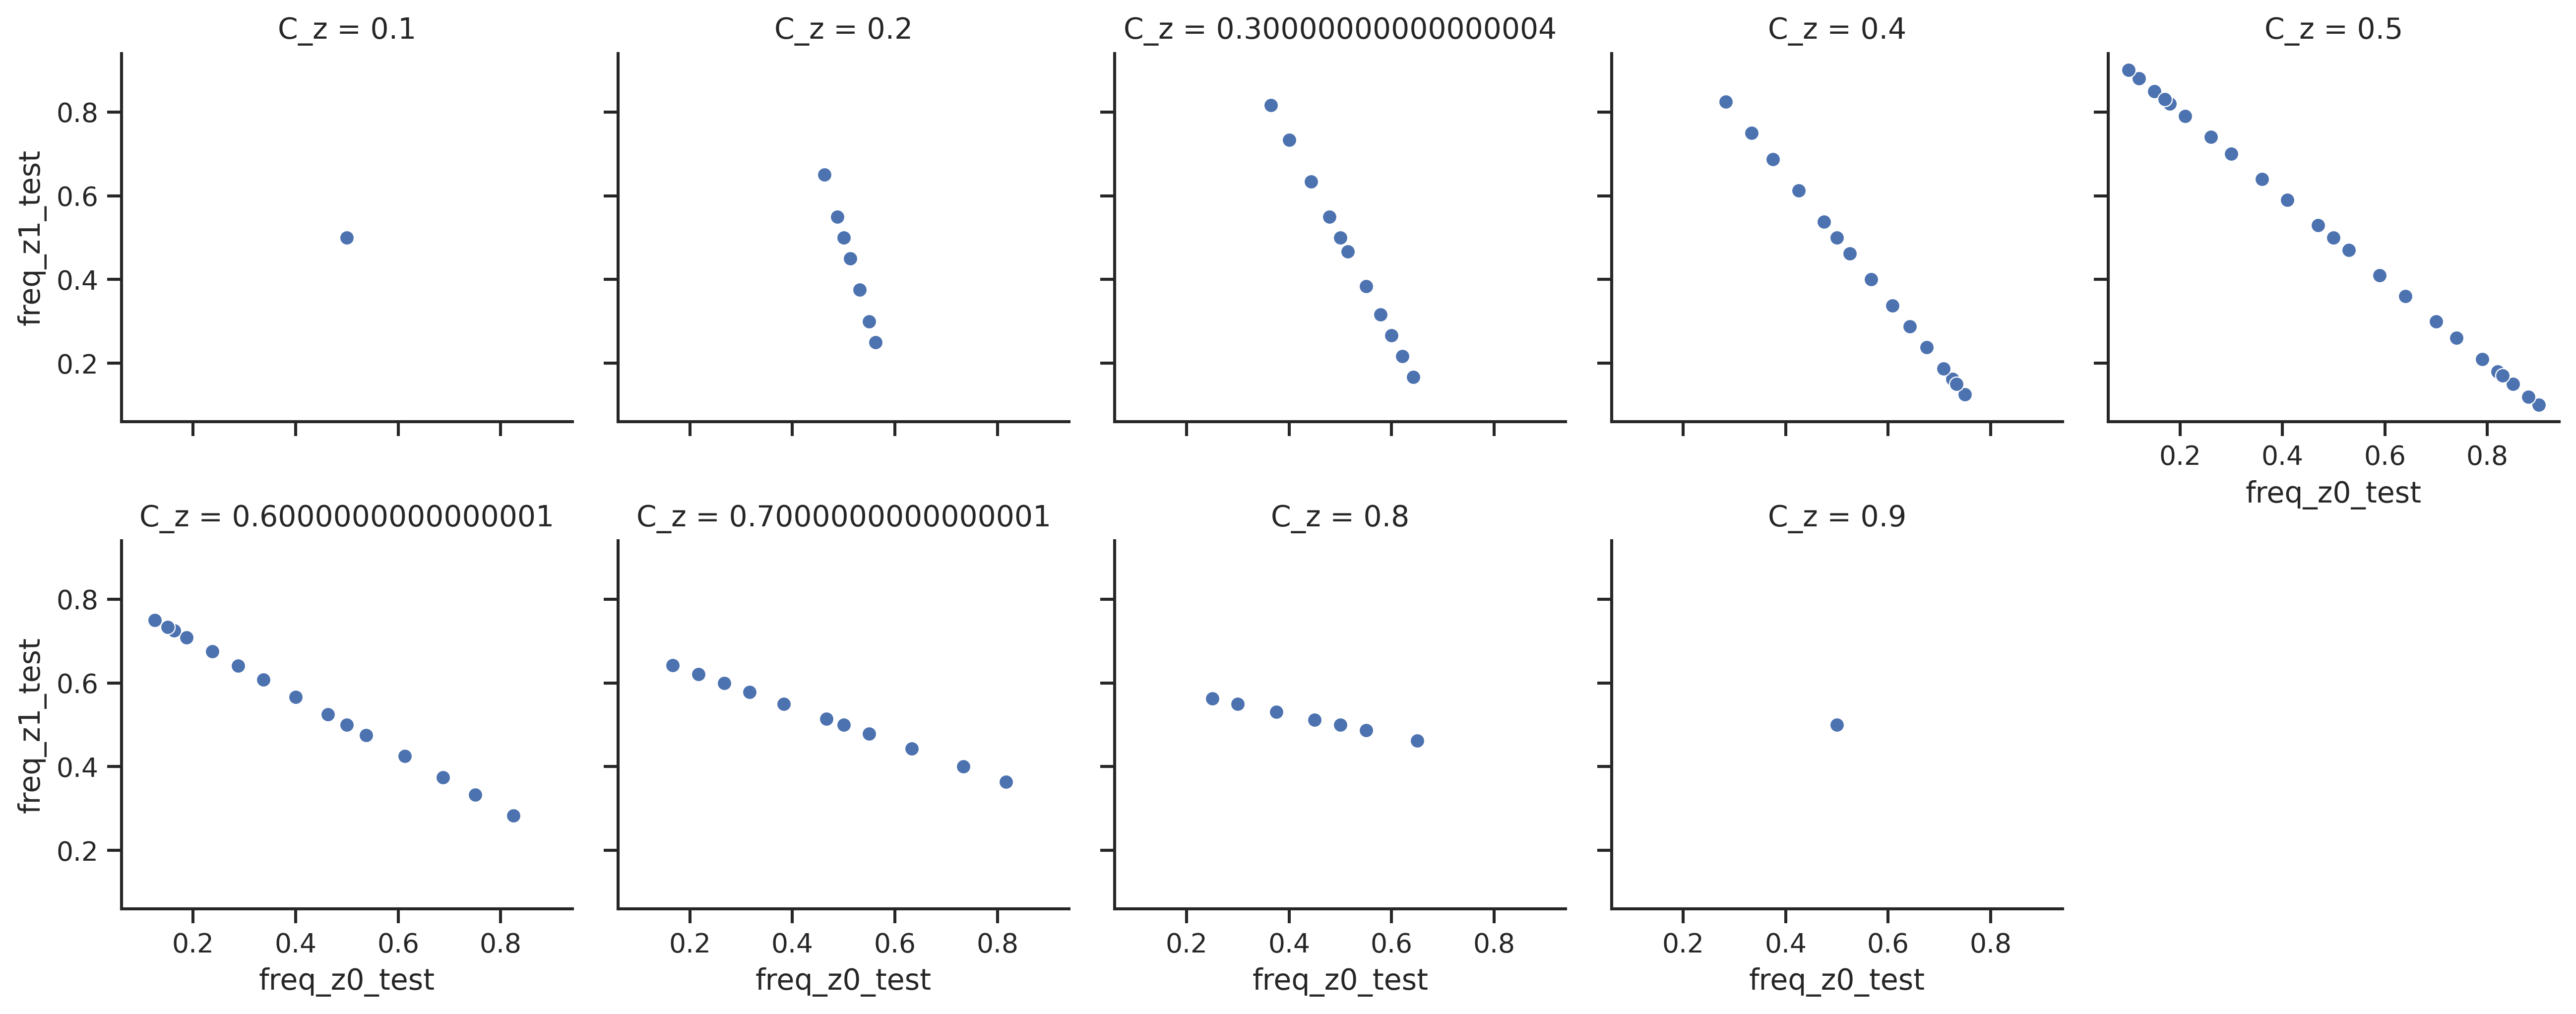

In [109]:
df_plt = deepcopy(df_eval.reset_index(drop=True))

df_plt["C_y"] = df_plt["C_y"].round(2)
df_plt = df_plt.query("C_y == 0.5")

g = sns.FacetGrid(data=df_plt, col="C_z", col_wrap=5)

g.map(sns.scatterplot, "freq_z0_test", "freq_z1_test")
plt.show()

In [190]:
sns.reset_defaults()
sns.set_theme(rc={"figure.dpi": 350})
sns.set_context("paper")


In [191]:
z_Categories

['avh', 'r56']

In [229]:
lambdaVar = "lambda2"
df_eval[lambdaVar] = df_eval[lambdaVar].astype(str)
lambdaVar_levels = ['0.0', '0.2', '0.4', '0.6', '0.8', '1.0', '1.2', '1.4', '1.6', '1.8', '2.0']

lambda_levels = lambda2_ls

df_eval[lambdaVar] = pd.Categorical(df_eval[lambdaVar], categories=lambdaVar_levels)

# savefig = False
savefig = True


outname = f"../output/TaskVectorFigs/fig_ScalingLambdas_byZ_{dataset_name}_{modelUsed}_Set_{set_i}_{source}_Cy_0.5_Cz_0.5.png"


df_plt = deepcopy(df_eval.reset_index(drop=True))

df_plt["C_y"] = df_plt["C_y"].round(2)
df_plt = df_plt.query("C_y == 0.5")
df_plt = df_plt.query("C_z == 0.5")


# lambda_ls = ["1.0-0.0", "1.0-0.2", "1.0-0.4", "1.0-0.6", "1.0-1.0", "1.0-1.4", "1.0-2.0", ]
lambda2_ls = ['0.0', '0.2', '0.4', '0.6',  '1.0',  '1.4', '2.0']


df_plt = df_plt[df_plt[lambdaVar].isin(lambda2_ls)]
df_plt[lambdaVar] = df_plt[lambdaVar].astype("str")

dashes_dict = {k:(("" if k != "0.0" else (4, 1.5)))  for k in lambda2_ls }


fig, axes = plt.subplots(1,2, figsize=(8, 4), sharey=True)
# axes = axes.ravel()

g = sns.lineplot(data=df_plt, x = "freq_z0_test", y = "auprc_weightsEdited_df0", ax=axes[0], hue=lambdaVar, palette="colorblind", style=lambdaVar, 
                 dashes=dashes_dict
                )
g = sns.lineplot(data=df_plt, x = "freq_z1_test", y = "auprc_weightsEdited_df1", ax=axes[1], hue=lambdaVar, palette="colorblind", style=lambdaVar, 
                 dashes=dashes_dict
                )

axes[0].set_ylabel("AUPRC")



for i in range(len(axes)):
    axes[i].set_xlabel(r"$P(Y=1|Z={})$".format("AVH" if z_Categories[i] == 'avh' else "TM"))

    axes[i].set_ylim(-0.02, 1.02)
    axes[i].legend(loc="lower right")
    axes[i].get_legend().set_title(r"$\lambda$")
    
# plt.legend(loc="lower right")
plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

In [222]:
##### No DAPER + DAPPER-O in one plot for easy comparison

lambdaVar = "lambda2"
df_eval[lambdaVar] = df_eval[lambdaVar].astype(str)
lambdaVar_levels = ['0.0', '0.2', '0.4', '0.6', '0.8', '1.0', '1.2', '1.4', '1.6', '1.8', '2.0']

lambda_levels = lambda2_ls

df_eval[lambdaVar] = pd.Categorical(df_eval[lambdaVar], categories=lambdaVar_levels)

# savefig = False
savefig = True


outname = f"../output/TaskVectorFigs/fig_Diag_byZ_{dataset_name}_{modelUsed}_Set_{set_i}_{source}_Cy_0.5_Cz_0.5.png"


df_plt = deepcopy(df_eval.reset_index(drop=True))

df_plt["C_y"] = df_plt["C_y"].round(2)
df_plt = df_plt.query("C_y == 0.5")
df_plt = df_plt.query("C_z == 0.5")


if set_i == 6621:
    
    lambda2_ls = ['0.0', '1.2'] ## for 6621 Optimal
elif set_i == 566:
    lambda2_ls = ['0.0', '1.4'] ## for 566 Optimal


df_plt = df_plt[df_plt[lambdaVar].isin(lambda2_ls)]
df_plt[lambdaVar] = df_plt[lambdaVar].astype("str")

dashes_dict = {k:(("" if k != "0.0" else (4, 1.5)))  for k in lambda2_ls }


fig, axes = plt.subplots(1,2, figsize=(8, 4), sharey=True)
# axes = axes.ravel()

for i in range(2):
    g = sns.lineplot(data=df_plt[df_plt[lambdaVar] == lambda2_ls[i]], x = "freq_z0_test", y = "auprc_weightsEdited_df0", ax=axes[i], label=r"{}".format("AVH" if z_Categories[0] == 'avh' else "TM")
                    )
    g = sns.lineplot(data=df_plt[df_plt[lambdaVar] == lambda2_ls[i]], x = "freq_z1_test", y = "auprc_weightsEdited_df1", ax=axes[i], label=r"{}".format("AVH" if z_Categories[1] == 'avh' else "TM")
                    )
    axes[i].set_xlabel(r"$P(Y=1|Z=z_i)$")


#     g = sns.lineplot(data=df_plt[df_plt[lambdaVar] == lambda2_ls[1]], x = "freq_z0_test", y = "auprc_weightsEdited_df0", ax=axes[1], 
#                     )
#     g = sns.lineplot(data=df_plt[df_plt[lambdaVar] == lambda2_ls[1]], x = "freq_z1_test", y = "auprc_weightsEdited_df1", ax=axes[1], 
#                     )


axes[0].set_ylabel("AUPRC")
axes[0].set_title("No DAPPER")
axes[1].set_title("DAPPER-O")


# for i in range(len(axes)):
#     axes[i].set_xlabel(r"$P(Y=1|Z={})$".format("AVH" if z_Categories[i] == 'avh' else "TM"))

#     axes[i].set_ylim(-0.02, 1.02)
#     axes[i].legend(loc="lower right")
#     axes[i].get_legend().set_title(r"$\lambda$")
    
# plt.legend(loc="lower right")
plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

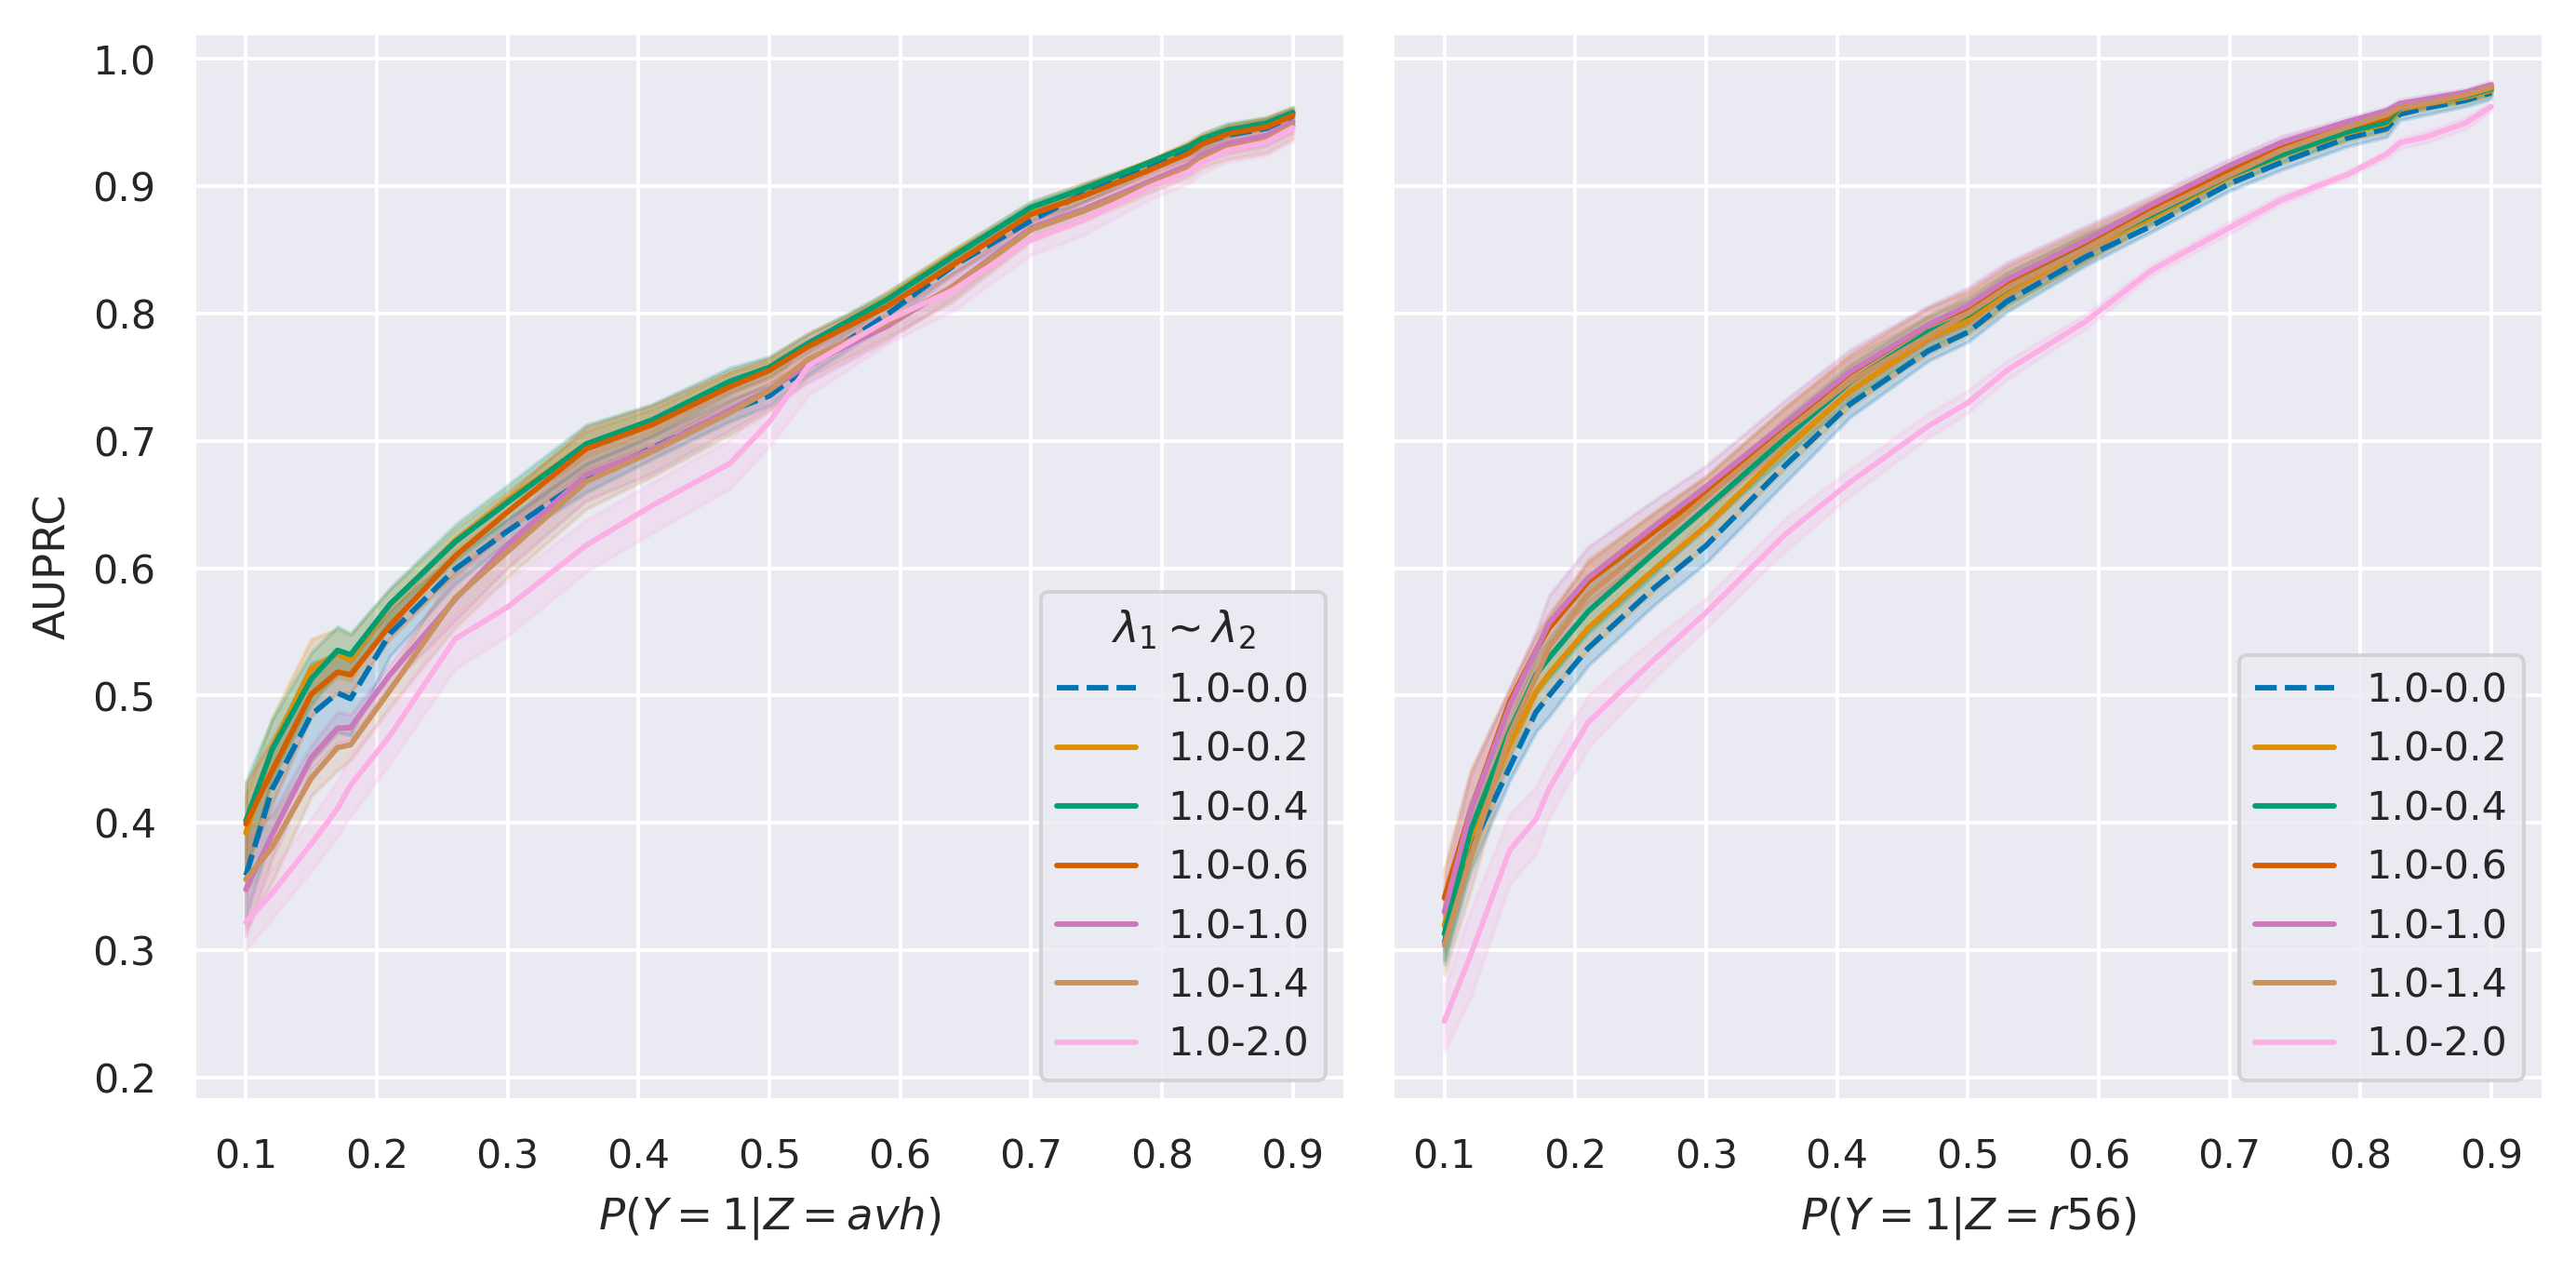

In [10]:
## Show both lambda 1 and lambda 2
savefig = False
# savefig = True


outname = f"../output/TaskVectorFigs/fig_ScalingLambdas_byZ_{dataset_name}_{modelUsed}_Set_{set_i}_{source}_Cy_0.5_Cz_0.5.png"


df_plt = deepcopy(df_eval.reset_index(drop=True))

df_plt["C_y"] = df_plt["C_y"].round(2)
df_plt = df_plt.query("C_y == 0.5")
df_plt = df_plt.query("C_z == 0.5")


lambda_ls = ["1.0-0.0", "1.0-0.2", "1.0-0.4", "1.0-0.6", "1.0-1.0", "1.0-1.4", "1.0-2.0", ]
df_plt = df_plt[df_plt[lambdaVar].isin(lambda_ls)]
df_plt[lambdaVar] = df_plt[lambdaVar].astype("str")

dashes_dict = {k:(("" if k != "1.0-0.0" else (4, 1.5)))  for k in lambda_ls }


fig, axes = plt.subplots(1,2, figsize=(8, 4), sharey=True)
axes = axes.ravel()
g = sns.lineplot(data=df_plt, x = "freq_z0_test", y = "auprc_weightsEdited_df0", ax=axes[0], hue=lambdaVar, palette="colorblind", style=lambdaVar, 
                 dashes=dashes_dict
                )
g = sns.lineplot(data=df_plt, x = "freq_z1_test", y = "auprc_weightsEdited_df1", ax=axes[1], hue=lambdaVar, palette="colorblind", style=lambdaVar, 
                 dashes=dashes_dict
                )

axes[0].set_ylabel("AUPRC")

axes[0].set_xlabel(r"$P(Y=1|Z={})$".format(z_Categories[0]))
axes[1].set_xlabel(r"$P(Y=1|Z={})$".format(z_Categories[1]))

for i in range(len(axes)):
    axes[i].get_legend().set_title(r"$\lambda_1 \sim \lambda_2$")
    
plt.legend(loc="lower right")
plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

# Backdoor as baseline

In [42]:
##
# # sets_ls = [6621, 3636, 566]
# # alpha_train_ls = [0.2,1,5]
# sets_reduce_ls = [6621, 566]
# alpha_train_reduce_ls = [0.2, 5]
# # dataset_name = 'HateSpeech'
# dataset_name = 'CD'

# sets_ls = [11063, 6114, 1152]
# alpha_train_ls = [0.2, 1, 5]
sets_reduce_ls = [11063, 1152]
alpha_train_reduce_ls = [0.2, 5]
dataset_name = 'SHAC'

In [43]:
fname_backdoor = "../output/backdoor/{}/backdoor/Eval-set-{}-irun-0-ntest_200-Runs_5.pkl"
fname_nobackdoor = "../output/backdoor/{}/noBackdoor/Eval-set-{}-irun-0-ntest_200-Runs_5.pkl"

# modelUsed = "Llama"
# # modelUsed = "RoBERTa"

# if modelUsed == "Llama":
#     fname_base = "../output/tmpData/{}/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl"
#     fname_edited = "../output/tmpData/{}/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5.pkl"

#     fname_reverse_base = "../output/tmpData/{}_ReverseSource/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl"
#     fname_reverse_edited = "../output/tmpData/{}_ReverseSource/Eval-set-{}-quantization-epoch3-llama-2-7B-loraR-8-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5.pkl"
# elif modelUsed == "RoBERTa":
#     fname_base = "../output/roberta/{}/Eval-set-{}-epoch3-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl"
#     fname_edited = "../output/roberta/{}/Eval-set-{}-epoch3-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5.pkl"

#     fname_reverse_base = "../output/roberta/{}_ReverseSource/Eval-set-{}-epoch3-lambda1_1.0-lambda2_0.0-added-ntest_200-Runs_5.pkl"
#     fname_reverse_edited = "../output/roberta/{}_ReverseSource/Eval-set-{}-epoch3-lambda1_1.0-lambda2_1.0-added-ntest_200-Runs_5.pkl"

In [44]:
df_ls = []

for set_i in sets_reduce_ls:
    # for nm in [fname_backdoor]:
    for nm in [fname_nobackdoor]:
        with open(nm.format(dataset_name, set_i), "rb") as f:
            df_tmp = pickle.load(file=f)
            
        df_tmp['set'] = set_i
        
        if "lambda2_0.0" in nm:
            df_tmp["lambda1_lambda2"] = "1.0-0.0"
            df_tmp["lambda2"] = 0.0
        elif "lambda2_1.0" in nm:
            df_tmp["lambda1_lambda2"] = "1.0-1.0"
            df_tmp["lambda2"] = 1.0
            
        if "Reverse" in nm:
            df_tmp['tv_direction'] = 'ReverseSource'
        else:
            df_tmp['tv_direction'] = 'Source'
        
        df_ls.append(df_tmp)
        del df_tmp
        
df_eval = pd.concat(df_ls).reset_index(drop=True)    


In [45]:
set_alpha_train_DICT = {566:5, 3636:1, 6621:0.2,
                        1152:5, 6114:1, 11063:0.2, 

                       }

In [46]:
sns.color_palette("colorblind", 10)

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [47]:
sets_reduce_ls

[11063, 1152]

0.2
count    45.000000
mean      0.889172
std       0.008848
min       0.872642
25%       0.889437
50%       0.891975
75%       0.893554
max       0.898250
Name: auprc_weightsEdited, dtype: float64
0.889 + 0.009
5
count    45.000000
mean      0.881353
std       0.021688
min       0.847351
25%       0.869617
50%       0.884783
75%       0.895475
max       0.909539
Name: auprc_weightsEdited, dtype: float64
0.881 + 0.022


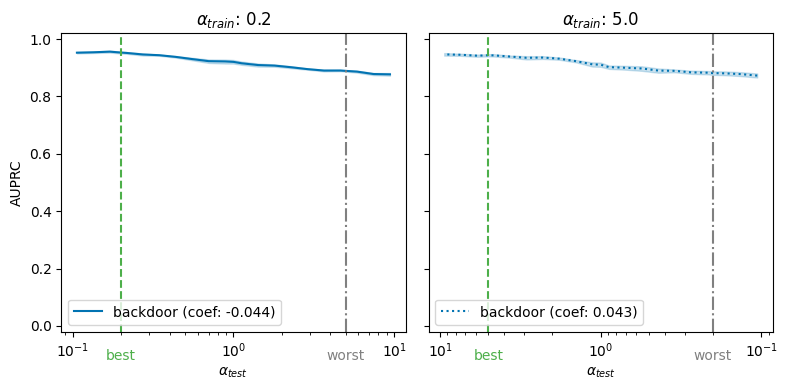

In [48]:
### All From Source

savefig = False
# savefig = True

my_palette = sns.color_palette("colorblind", 2)
my_linestyle = ['solid','dotted']
xticks = [0.1,1,10]

# sr = "Source"
# # sr = "ReverseSource"

# outname = f"../output/TaskVectorFigs/fig_NoDAAllSource_{dataset_name}_{modelUsed}_{sr}_Cz_0.5_Cy_0.5.pngXXXXXXXXXXXXXX"

_df = deepcopy(df_eval)

_df = _df.query("C_y.isin([0.5])").query("C_z == 0.5").reset_index(drop=True)

# _df['alpha_test'] = _df.apply(lambda x: 1/x['alpha_test'] if x['set'] in [566, 1152] else x['alpha_test'], axis=1)


xname = "alpha_test"
ylabel = "auprc_weightsEdited"

fig, ax = plt.subplots(1,2, figsize=(8,4), sharey=True)



for i, (set_i, alpha_train) in enumerate(zip(sets_reduce_ls, alpha_train_reduce_ls)):
    df_sub = _df[_df['set'] == set_i]
    
    txt_worst_summary = df_sub.query(f"alpha_test == {1/set_alpha_train_DICT[set_i]}")[ylabel].describe()
    print(alpha_train)
    print(txt_worst_summary)
    print(f"{txt_worst_summary['mean']:.3f} + {txt_worst_summary['std']:.3f}")

   
    # _df_plt = df_sub[df_sub['lambda1_lambda2'] == lambda_com].copy()
    reg = get_coefLog10(x=list(df_sub[xname]), y=list(df_sub[ylabel]))

    sns.lineplot(data=df_sub, x=xname, y=ylabel, ax=ax[i], 
                 c=my_palette[0], 
                 linestyle=my_linestyle[i], label=f"backdoor" + f" (coef: {reg[0]:.3f})"
                )
        

    ax[i].set_xscale('log')
    
    ax[i].axvline(set_alpha_train_DICT[set_i], color="#4DAF4A", linestyle='dashed')
    ax[i].axvline(1/set_alpha_train_DICT[set_i], color="grey", linestyle='dashdot')
    ax[i].text(x=set_alpha_train_DICT[set_i], y=-0.12, s='best', color="#4DAF4A", fontsize=10, horizontalalignment='center')
    ax[i].text(x=1/set_alpha_train_DICT[set_i], y=-0.12, s='worst', color="grey", fontsize=10, horizontalalignment='center')

    ax[i].title.set_text(r"$\alpha_{train}$" + f": {alpha_train:.1f}")
    ax[i].set_ylim((-0.02,1.02))
    ax[i].set_xticks(xticks)
    ax[i].legend(loc="lower left")
    ax[i].set_xlabel(r"$\alpha_{test}$")
    ax[i].set_ylabel("AUPRC")
    
    if set_i in [566, 1152]:
        ax[i].invert_xaxis()


plt.tight_layout()

if savefig:
    plt.savefig(outname, dpi=600, bbox_inches='tight')
else:
    plt.show()

plt.close()

In [29]:
df_sub.query("alpha_test == 0.2")[ylabel].describe()

count    45.000000
mean      0.741170
std       0.030391
min       0.685258
25%       0.739915
50%       0.746455
75%       0.764484
max       0.769738
Name: auprc_weightsEdited, dtype: float64